# Imports & Helpers

In [ ]:
!pip install pingouin

In [1]:
import pandas as pd
import ast
import seaborn as sns
sns.set_style("white")
import matplotlib.pyplot as plt
from scipy.stats import sem
import numpy as np
from scipy import stats
from sklearn.metrics import pairwise_distances
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
folder_path = "/content/drive/MyDrive/World Bank/Metanorms/"

## Helpers

In [2]:
# Define choice lists with numeric anchors
EMOTIONS = [
    "Contempt", "Anger", "Disgust",
    "Shame", "Embarrassment", "Guilt",
    "Compassion", "Pride",
    "Other", "No emotion"
]

STRENGTHS = [
    "1 = A little", "2 = Moderate", "3 = A lot", "4 = Extremely"
]

ACTIONS = [
    "1 = Do nothing",
    "2 = Stay away or keep a distance from the actor",
    "3 = Gossip about / discuss with / complain to others informally",
    "4 = Verbal reprimand / verbal confrontation",
    "5 = Physical confrontation", # isn't present in results for GPT
    "6 = Inform the authorities, such as the police",
    "7 = Support the actor",
    "8 = Celebrate / praise"
]

APPROPRIATENESS = [
    "1 = Not at all inappropriate",
    "2 = Somewhat inappropriate",
    "3 = Inappropriate",
    "4 = Very inappropriate",
    "5 = Extremely inappropriate"
]

WRONGNESS = [
    "1 = Not at all wrong",
    "2 = Somewhat wrong",
    "3 = Wrong",
    "4 = Very wrong",
    "5 = Extremely wrong"
]

In [3]:
emotions_keep = [
    "Pride", "Compassion", "Anger", "Contempt",
    "Disgust", "Embarrassment", "Guilt", "Shame"
]

In [4]:
tie_map = {
    "friends": "strong",
    "acquaintances": "weak",
    "strangers": "weak"
}

In [5]:
# Parse dict-like columns into real Python dicts
dict_cols = [
    "actor_emotions", "actor_emotion_strength",
    "friends_emotions", "friends_emotion_strength",
    "acquaintances_emotions", "acquaintances_emotion_strength",
    "strangers_emotions", "strangers_emotion_strength"
]

In [6]:
def expand_strengths(df, col, actor_label, observer_label=None):
    records = []
    for _, row in df.iterrows():
        if isinstance(row[col], dict):
            for emo, val in row[col].items():
                records.append({
                    "ID": row["ID"],
                    "actor": actor_label,        # friends / acquaintances / strangers
                    "gender": row["gender"],
                    "observer": observer_label,  # LLM name
                    "emotion": emo,
                    "strength": val
                })
    return pd.DataFrame(records)

In [7]:
# Function to return CI bounds
def ci_bounds(x, confidence=0.95):
    x = np.array(x.dropna())  # drop NaNs if any
    if len(x) <= 1:
        return (np.nan, np.nan)
    mean = np.mean(x)
    sem = stats.sem(x)  # standard error of the mean
    h = sem * stats.t.ppf((1 + confidence) / 2., len(x)-1)
    return mean - h, mean + h

In [8]:
def aggregate_emotions(df, group_cols):
    """
    Aggregate emotion data with frequency, mean, std, and 95% CI.

    Parameters:
    -----------
    df : pd.DataFrame
        Long-format dataframe with at least ["emotion", "strength"].
    group_cols : list of str
        Columns to group by (e.g. ["observer", "gender", "emotion"]).

    Returns:
    --------
    pd.DataFrame
        Aggregated dataframe with frequency, avg_strength, std_strength,
        ci_lower, ci_upper.
    """
    agg = (
        df
        .groupby(group_cols)
        .agg(
            frequency=("emotion", "count"),
            avg_strength=("strength", "mean"),
            std_strength=("strength", "std"),
            ci=("strength", ci_bounds)
        )
        .reset_index()
    )

    # Split CI into lower/upper columns
    agg[["ci_lower", "ci_upper"]] = pd.DataFrame(agg["ci"].tolist(), index=agg.index)
    agg = agg.drop(columns=["ci"])

    return agg

In [9]:
def aggregate_by_gender(df, tie="strong", col='observer'):
    df_sub = df[df["tie_strength"] == tie]
    agg_df = aggregate_emotions(df_sub, [col, "gender", "emotion"])
    return agg_df

In [41]:
def plot_emotion_panels(
    prop_df,
    icc_df=None,
    strength_df=None,
    roles_order=['actor', 'friends', 'acquaintances', 'strangers'],
    emotion_order=None
):
    """
    Create a panel plot showing emotion proportions per role (bar height),
    with optional annotations (ICCs or mean±SE), fixed emotion order,
    and automatic 2×2 layout if there are 4 roles.
    """

    # --- Fixed emotion order ---
    if emotion_order is None:
        emotion_order = [
            'Shame', 'Guilt', 'Embarrassment', 'Anger',
            'Contempt', 'Disgust', 'Pride', 'Compassion'
        ]

    # --- Ensure consistent indexing ---
    prop_df = prop_df.reindex(emotion_order)
    if icc_df is not None:
        icc_df = icc_df.reindex(emotion_order)
    if strength_df is not None:
        strength_df = strength_df.reindex(emotion_order)

    # --- Keep only relevant role columns ---
    prop_df = prop_df[roles_order]
    if icc_df is not None:
        icc_df = icc_df[roles_order]
    if strength_df is not None:
        strength_df = strength_df[roles_order]

    # --- Use Seaborn "Set2" palette ---
    palette = sns.color_palette("Set2", n_colors=len(emotion_order))
    emotion_colors = {emotion: palette[i % len(palette)] for i, emotion in enumerate(emotion_order)}

    # --- Determine subplot layout ---
    n_roles = len(roles_order)
    if n_roles == 4:
        nrows, ncols = 2, 2
        figsize = (12, 12)
    else:
        nrows, ncols = 1, n_roles
        figsize = (5 * n_roles, 5)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = np.ravel(axes)
    fig.subplots_adjust(wspace=0.25, hspace=0.35)

    # --- Determine title suffix based on data type ---
    if icc_df is not None:
        title_suffix = "(ICC shown above bars)"
    elif strength_df is not None:
        title_suffix = "(Mean ± SE shown above bars)"
    else:
        title_suffix = ""

    # --- Plot each role ---
    for i, role in enumerate(roles_order):
        ax = axes[i]
        props = prop_df[role]

        bars = ax.bar(
            emotion_order,
            props,
            color=[emotion_colors[e] for e in emotion_order],
            edgecolor='black',
            width=0.7
        )
        ax.tick_params(axis='y', labelsize=24)

        # --- Add annotations ---
        if icc_df is not None:
            iccs = icc_df[role]
            for bar, icc_val in zip(bars, iccs):
                if pd.notnull(icc_val):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.03,
                        f"{icc_val:.2f}",
                        ha='center', va='bottom',
                        fontsize=24, rotation=90
                    )

        elif strength_df is not None:
            for bar, val in zip(bars, strength_df[role]):
                if pd.notnull(val):
                    if isinstance(val, (tuple, list)) and len(val) == 2:
                        mean, se = val
                        text = f"{mean:.2f}±{se:.2f}"
                    else:
                        text = str(val)
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.03,
                        text,
                        ha='center', va='bottom',
                        fontsize=24, rotation=90
                    )

        # --- Formatting ---
        ax.set_ylim(0, 1)
        ax.set_title(role.capitalize(), fontsize=24, fontweight='bold')
        ax.set_xticks(range(len(emotion_order)))
        ax.set_xticklabels(emotion_order, rotation=45, ha='right', fontsize=24)
        
        if i % ncols == 0:  # Left column only
            ax.set_ylabel('Proportion', fontsize=24)
        ax.grid(alpha=0.2, axis='y')
        ax.set_axisbelow(True)

    # --- Remove unused subplots if any ---
    for j in range(len(roles_order), len(axes)):
        fig.delaxes(axes[j])

    # --- Shared main title ---
    fig.suptitle(
        f"Proportion of Each Emotion by Role\n{title_suffix}",
        fontsize=24, fontweight='bold', y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [11]:
def plot_action_panels(
    prop_actions,
    ICC_visualise=None,
    roles_order=['friends', 'acquaintances', 'strangers'],
    title_suffix=""
):
    """
    Create a 1x3 panel plot showing action proportions per role (bar height)
    and optionally ICC(2,1) values as labels above bars.

    Parameters
    ----------
    prop_actions : dict or pd.DataFrame
        Action proportions (rows = actions, cols = roles)
    ICC_visualise : dict or pd.DataFrame, optional
        ICC(2,1) values (rows = actions, cols = roles). If None, no annotations are shown.
    roles_order : list of str
        Roles to display (default: ['friends', 'acquaintances', 'strangers'])
    title_suffix : str
        Extra text for the plot title
    """
    # --- Step 1: Create proportion DataFrame ---
    prop_df_actions = pd.DataFrame(prop_actions)
    prop_df_actions = prop_df_actions[roles_order]

    # --- Step 2: Optional ICC DataFrame ---
    icc_df_actions = None
    if ICC_visualise is not None:
        icc_df_actions = pd.DataFrame(ICC_visualise)
        icc_df_actions = icc_df_actions.reindex(index=prop_df_actions.index, columns=roles_order)

    # --- Step 3: Shorten long action labels ---
    action_short_names = {
        'Do nothing': 'Do nothing',
        'Stay away or keep a distance from the actor': 'Stay away',
        'Gossip about / discuss with / complain to others informally': 'Gossip',
        'Verbal reprimand / verbal confrontation': 'Verbal reprimand',
        'Physical confrontation': 'Physical confrontation',
        'Inform the authorities, such as the police': 'Inform authorities',
        'Support the actor': 'Support actor',
        'Celebrate / praise': 'Celebrate'
    }
    prop_df_actions.index = [action_short_names.get(a, a) for a in prop_df_actions.index]
    if icc_df_actions is not None:
        icc_df_actions.index = prop_df_actions.index

    # --- Step 4: Define consistent colors per action ---
    palette = sns.color_palette("Set2", n_colors=len(action_short_names))
    action_colors = {action: palette[i % len(palette)] for i, action in enumerate(prop_df_actions.index)}

    # --- Step 5: Create 1x3 subplot layout ---
    n_roles = len(roles_order)
    fig, axes = plt.subplots(1, n_roles, figsize=(15, 5), sharey=True)
    fig.subplots_adjust(wspace=0.25, hspace=0.3)

    for i, role in enumerate(roles_order):
        ax = axes[i]
        props = prop_df_actions[role]
        bars = ax.bar(
            prop_df_actions.index,
            props,
            color=[action_colors[a] for a in prop_df_actions.index],
            edgecolor='black',
            width=0.7
        )

        # --- Step 6: Add ICC annotations only if provided ---
        if icc_df_actions is not None:
            iccs = icc_df_actions[role]
            for bar, icc_val in zip(bars, iccs):
                if pd.notnull(icc_val):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.03,
                        f"{icc_val:.2f}",
                        ha='center', va='bottom', fontsize=8, rotation=90
                    )

        # --- Formatting per subplot ---
        ax.set_ylim(0, 1)
        ax.set_title(role.capitalize(), fontsize=12, fontweight='bold')
        ax.set_xticklabels(prop_df_actions.index, rotation=45, ha='right', fontsize=10)
        if i == 0:
            ax.set_ylabel('Proportion', fontsize=11)
        ax.grid(alpha=0.2, axis='y')
        ax.set_axisbelow(True)

    # --- Step 7: Shared main title ---
    if icc_df_actions is not None:
        subtitle = "(ICC shown above bars)"
    else:
        subtitle = ""
    fig.suptitle(
        f"Proportion of Each Action by Role {title_suffix}\n{subtitle}",
        fontsize=14,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [12]:
def plot_bubble(df, column, y_column, plt_type, palette="Blues"):
    """
    Create and save a bubble plot for emotions.

    Parameters:
    -----------
    df : pd.DataFrame
        Aggregated dataframe (must include frequency, avg_strength, emotion, y_column, column).
    column : str
        The variable to facet into panels (e.g. "gender", "tie_strength").
    y_column : str
        The variable to plot on the y-axis (e.g. "observer", "MFT").
    plt_type : str
        The variable to specify the plot
    palette : str
        Colormap for bubble colors (default = "Blues").
    """

    # Replace labels for gender if present
    if "gender" in df.columns:
        df["gender"] = df["gender"].replace({"female": "women", "male": "men"})
    if "tie_strength" in df.columns:
        df["tie_strength"] = df["tie_strength"].replace({"strong": "strong tie", "weak": "weak tie"})

    if column == 'gender':
        col_order = ['men', 'women']
    elif column == 'tie_strength':
        col_order = ['strong tie', 'weak tie']

    # Style
    sns.set_style("whitegrid", {"grid.linewidth": 0.5, "grid.alpha": 0.5})

    # Create relplot
    g = sns.relplot(
        data=df,
        x="emotion",
        y=y_column,
        size="frequency",
        hue="avg_strength",
        col=column,
        col_order=col_order,
        kind="scatter",
        height=8,
        aspect=0.8,
        sizes=(40, 400),
        palette=palette,
        alpha=0.7,
        facet_kws={'sharey': True, 'sharex': False}
    )

    # Style each subplot
    for ax in g.axes.flat:
        ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.3, color='#E0E0E0')
        ax.set_facecolor('#FAFAFA')

        # Bubble edges
        for collection in ax.collections:
            collection.set_edgecolors('white')
            collection.set_linewidth(0.8)

        # Axis styling
        ax.tick_params(axis='x', rotation=90, labelsize=9, pad=2)
        ax.tick_params(axis='y', labelsize=9, pad=2)

        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)

    # Titles & labels
    g.set_titles("{col_name}", size=12, weight='bold', pad=20)
    g.set_axis_labels("", "")

    # Remove legends
    if g._legend:
        g._legend.remove()
    for ax in g.axes.flat:
        legend = ax.get_legend()
        if legend:
            legend.remove()

    # ---- Custom colorbar ----
    norm = plt.Normalize(vmin=1, vmax=5)
    sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
    sm.set_array([])
    g.fig.subplots_adjust(right=0.88)
    cbar_ax = g.fig.add_axes([0.9, 0.15, 0.02, 0.75])
    cbar = g.fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Strength (1–5)', rotation=270, labelpad=20, fontsize=10)
    cbar.set_ticks([1, 2, 3, 4, 5])
    cbar.ax.tick_params(labelsize=9)

    # Layout
    plt.tight_layout()
    plt.subplots_adjust(right=0.88, top=0.9)
    g.fig.patch.set_facecolor('white')

    # Save figure
    filename = f"{plt_type}_{y_column}_emotion_{column}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Load Data

In [14]:
folder_path_data="../data/"
folder_path_output_closed = "../output/closed-source"
folder_path_output_open = "../output/open-source"

In [16]:
# Load CSV file
df = pd.read_csv(folder_path_data+"rotexamples_07072025.csv")
df_gender = pd.read_csv(folder_path_data+"rotexamples_07072025_genders.csv")

df_gpt_41 = pd.read_csv(folder_path_output_closed+"/gpt_4.1_responses.csv")
df_gpt_5 = pd.read_csv(folder_path_output_closed+"/gpt_5_responses.csv")
df_gpt = pd.read_csv(folder_path_output_closed+"/gpt_4.1_responses.csv")
df_claude = pd.read_csv(folder_path_output_closed+"/claude_responses.csv")
df_gemini = pd.read_csv(folder_path_output_closed+"/gemini_responses.csv")

df_gpt_oss = pd.read_csv(folder_path_output_open+"/gpt_oss_responses.csv")
df_gemma = pd.read_csv(folder_path_output_open+"/gemma_responses.csv")
df_llama = pd.read_csv(folder_path_output_open+"/llama_responses.csv")

df_gpt_41_gender = pd.read_csv(folder_path_output_closed+"/gender_salience/gpt_4.1_responses.csv")
df_gpt_5_gender = pd.read_csv(folder_path_output_closed+"/gender_salience/gpt_5_responses.csv")
df_gpt_gender = pd.read_csv(folder_path_output_closed+"/gender_salience/gpt_4.1_responses.csv")
df_claude_gender = pd.read_csv(folder_path_output_closed+"/gender_salience/claude_responses.csv")
df_gemini_gender = pd.read_csv(folder_path_output_closed+"/gender_salience/gemini_responses.csv")

df_gpt_oss_gender = pd.read_csv(folder_path_output_open+"/gender_salience/gpt_oss_responses.csv")
df_gemma_gender = pd.read_csv(folder_path_output_open+"/gender_salience/gemma_responses.csv")
df_llama_gender = pd.read_csv(folder_path_output_open+"/gender_salience/llama_responses.csv")

In [ ]:
# # Load CSV file
# df = pd.read_csv(folder_path+"rotexamples_07072025.csv")
# df_gender = pd.read_csv(folder_path+"rotexamples_07072025_genders.csv")

In [ ]:
# df_gpt_41 = pd.read_csv(folder_path+"Character/gpt_4.1_responses.csv")
# df_gpt_5 = pd.read_csv(folder_path+"Character/gpt_5_responses.csv")
# df_gpt = pd.read_csv(folder_path+"Character/gpt_4.1_responses.csv")
# df_claude = pd.read_csv(folder_path+"Character/claude_responses.csv")
# df_gemini = pd.read_csv(folder_path+"Character/gemini_responses.csv")
# df_gpt_oss = pd.read_csv(folder_path+"Character/gpt_oss_responses.csv")
# df_gemma = pd.read_csv(folder_path+"Character/gemma_responses.csv")
# df_llama = pd.read_csv(folder_path+"Character/llama_responses.csv")

# df_gpt_41_gender = pd.read_csv(folder_path+"Gender/gpt_4.1_responses.csv")
# df_gpt_5_gender = pd.read_csv(folder_path+"Gender/gpt_5_responses.csv")
# df_gpt_gender = pd.read_csv(folder_path+"Gender/gpt_4.1_responses.csv")
# df_claude_gender = pd.read_csv(folder_path+"Gender/claude_responses.csv")
# df_gemini_gender = pd.read_csv(folder_path+"Gender/gemini_responses.csv")
# df_gpt_oss_gender = pd.read_csv(folder_path+"Gender/gpt_oss_responses.csv")
# df_gemma_gender = pd.read_csv(folder_path+"Gender/gemma_responses.csv")
# df_llama_gender = pd.read_csv(folder_path+"Gender/llama_responses.csv")

In [17]:
for col in dict_cols:
    df_gpt_41[col] = df_gpt_41[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt_5[col] = df_gpt_5[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt[col] = df_gpt[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_claude[col] = df_claude[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gemini[col] = df_gemini[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gemma[col] = df_gemma[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_llama[col] = df_llama[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt_oss[col] = df_gpt_oss[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)

    df_gpt_41_gender[col] = df_gpt_41_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt_5_gender[col] = df_gpt_5_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt_gender[col] = df_gpt_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_claude_gender[col] = df_claude_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gemini_gender[col] = df_gemini_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gemma_gender[col] = df_gemma_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_llama_gender[col] = df_llama_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)
    df_gpt_oss_gender[col] = df_gpt_oss_gender[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)

In [18]:
# Select only the relevant metadata columns
meta = df[["ID", "MFT", "rot-agree", "action-agree", "action-pressure", "action-hypothetical"]]

# Merge each model dataframe with the metadata
df_gpt_41  = df_gpt_41.merge(meta, on="ID", how="inner")
df_gpt_5   = df_gpt_5.merge(meta, on="ID", how="inner")
df_gemma   = df_gemma.merge(meta, on="ID", how="inner")
df_claude  = df_claude.merge(meta, on="ID", how="inner")
df_gemini  = df_gemini.merge(meta, on="ID", how="inner")
df_gpt_oss = df_gpt_oss.merge(meta, on="ID", how="inner")
df_llama   = df_llama.merge(meta, on="ID", how="inner")

df_gpt_41_gender  = df_gpt_41_gender.merge(meta, on="ID", how="inner")
df_gpt_5_gender   = df_gpt_5_gender.merge(meta, on="ID", how="inner")
df_gemma_gender   = df_gemma_gender.merge(meta, on="ID", how="inner")
df_claude_gender  = df_claude_gender.merge(meta, on="ID", how="inner")
df_gemini_gender  = df_gemini_gender.merge(meta, on="ID", how="inner")
df_gpt_oss_gender = df_gpt_oss_gender.merge(meta, on="ID", how="inner")
df_llama_gender   = df_llama_gender.merge(meta, on="ID", how="inner")

# Agreement across LLMs

## Expanding Emotions

In [19]:
def expand_emotions(
    df,
    emotions_col='actor_emotions',
    strength_col='actor_emotion_strength',
    prefix='',
    fill=0,
    restrict_to_list=False,
    allowed_emotions=None
):
    # Default allowed emotions list if not provided
    if allowed_emotions is None:
        allowed_emotions = [
                'Anger', 'Compassion', 'Contempt', 'Disgust',  'Embarrassment', 'Guilt', 'Pride', 'Shame'
        ]

    # Helper to get the first dict if cell is a list, else cell itself if a dict, else {}
    def get_first_dict(cell):
        if isinstance(cell, list):
            return cell[0] if cell else {}
        elif isinstance(cell, dict):
            return cell
        else:
            return {}

    # Get first relevant actor_emotions dict for each row
    first_emo_dicts = df[emotions_col].apply(get_first_dict)

    # Get emotion list and strengths per row
    emo_lists = first_emo_dicts.apply(lambda d: d.get('emotions', []) if isinstance(d, dict) else [])
    strengths = df[strength_col].apply(lambda d: d if isinstance(d, dict) else {})

    # Build row dicts only for allowed_emotions
    row_dicts = []
    if restrict_to_list:
        for emos, s in zip(emo_lists, strengths):
            row = {e: s.get(e, fill) for e in emos if e in allowed_emotions}
            row_dicts.append(row)
    else:
        for emos, s in zip(emo_lists, strengths):
            # collect from both emos (if they are allowed) and from s (in allowed_emotions)
            merged = {e: fill for e in emos if e in allowed_emotions}
            for k in s:
                if k in allowed_emotions:
                    merged[k] = s.get(k, fill)
            row_dicts.append(merged)

    wide_df = pd.json_normalize(row_dicts).fillna(fill)

    # Coerce to numeric; int if fill is int
    for col in wide_df.columns:
        wide_df[col] = pd.to_numeric(wide_df[col], errors='coerce').fillna(fill)
    if isinstance(fill, (int, np.integer)):
        wide_df = wide_df.astype(int)

    if prefix:
        wide_df = wide_df.add_prefix(prefix)
    out = pd.concat([df.reset_index(drop=True), wide_df.reset_index(drop=True)], axis=1)
    return out

In [20]:
def expand_all_roles(
    df,
    roles=('actor', 'friends', 'acquaintances', 'strangers'),
    allowed_emotions=None,
    fill=0
):
    if allowed_emotions is None:
        allowed_emotions = [
            'Anger', 'Compassion', 'Contempt', 'Disgust',  'Embarrassment', 'Guilt', 'Pride', 'Shame'
        ]
    expanded_dfs = []
    for role in roles:
        # Compose column names for this role
        emotions_col = f'{role}_emotions'
        strength_col = f'{role}_emotion_strength'
        # Expand using previous function, with prefix
        expanded = expand_emotions(
            df,
            emotions_col=emotions_col,
            strength_col=strength_col,
            prefix=f'{role}_',
            fill=fill,
            restrict_to_list=False,
            allowed_emotions=allowed_emotions
        )
        # Keep only the new columns starting with this prefix
        new_cols = [col for col in expanded.columns if col.startswith(f"{role}_")]
        expanded_dfs.append(expanded[new_cols])
    # Concatenate along columns (axis=1)
    all_expanded = pd.concat(expanded_dfs, axis=1)
    # Attach to original DataFrame (drop duplicated columns if re-running)
    # Avoid duplicating columns by dropping any columns in all_expanded that already exist in df
    cols_to_add = [col for col in all_expanded.columns if col not in df.columns]
    result = pd.concat(
        [df.reset_index(drop=True), all_expanded[cols_to_add].reset_index(drop=True)],
        axis=1
    )
    #result = result.drop_duplicates()
    return result

In [21]:
df_gpt_41  = expand_all_roles(df_gpt_41)
df_gpt_5   = expand_all_roles(df_gpt_5)
df_gemma   = expand_all_roles(df_gemma)
df_claude  = expand_all_roles(df_claude)
df_gemini  = expand_all_roles(df_gemini)
df_gpt_oss = expand_all_roles(df_gpt_oss)
df_llama   = expand_all_roles(df_llama)

## Emotion

### Correlation

In [22]:
def get_emotion_matrix(dfs, names, role, emotion, id_col):
    colname = f"{role}_{emotion}"
    emotion_series = []
    for df, name in zip(dfs, names):
        if colname in df.columns:
            s = df.set_index(id_col)[colname]
        else:
            s = pd.Series(0, index=df[id_col])
        s = pd.to_numeric(s, errors='coerce')
        s.name = name
        emotion_series.append(s)
    matrix = pd.concat(emotion_series, axis=1)
    return matrix

In [23]:
roles = ['actor', 'friends', 'acquaintances', 'strangers']
dfs = [df_gpt_41, df_gpt_5, df_gemma, df_claude, df_gemini, df_gpt_oss, df_llama]
names = ['gpt_41', 'gpt_5', 'gemma', 'claude', 'gemini', 'gpt_oss', 'llama']
emotions = ['Anger', 'Compassion', 'Contempt', 'Disgust',  'Embarrassment', 'Guilt', 'Pride', 'Shame']
id_col = 'ID'

# Nested dict: emotion_matrix[role][emotion] = df
emotion_matrix = {role: {} for role in roles}
for role in roles:
    for emotion in emotions:
        emotion_matrix[role][emotion] = get_emotion_matrix(dfs, names, role, emotion, id_col)

In [24]:
corr_matrix = {}
for role in roles:
    corr_matrix[role] = {}  # initialize inner dict
    for emotion in emotions:
        corr_matrix[role][emotion] = emotion_matrix[role][emotion].corr(method='spearman')

In [25]:
def plot_lower_triangle_heatmap(corr_matrix, title="Lower Triangle Correlation Heatmap"):
    # Mask to show only lower triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='RdBu',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        square=True,
        mask=mask,
        cbar=True
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# for emotion, matrix in corr_matrix.items():
#     print("Plotting correlation matrix")
#     plot_lower_triangle_heatmap(
#         matrix,
#         title=f"Correlation for {emotion} (Lower Triangle)"
#     )

for social_tie, emotion_dict in corr_matrix.items():
    for emotion, matrix in emotion_dict.items():
        print(f"Plotting correlation matrix for {social_tie} - {emotion}")
        plot_lower_triangle_heatmap(
            matrix,
            title=f"Correlation for {social_tie} - {emotion} (Lower Triangle)"
        )

### ICC

In [27]:
def get_ICC(response_matrix, id_col):
    scores_long = response_matrix.reset_index().melt(id_vars=id_col, var_name='system', value_name='score')
    icc_res = pg.intraclass_corr(data=scores_long, targets=id_col, raters='system', ratings='score')
    return icc_res[icc_res['Type'] == 'ICC2']

In [28]:
for role in roles:
    print(f"{role}: {list(emotion_matrix[role].keys())}")

actor: ['Anger', 'Compassion', 'Contempt', 'Disgust', 'Embarrassment', 'Guilt', 'Pride', 'Shame']
friends: ['Anger', 'Compassion', 'Contempt', 'Disgust', 'Embarrassment', 'Guilt', 'Pride', 'Shame']
acquaintances: ['Anger', 'Compassion', 'Contempt', 'Disgust', 'Embarrassment', 'Guilt', 'Pride', 'Shame']
strangers: ['Anger', 'Compassion', 'Contempt', 'Disgust', 'Embarrassment', 'Guilt', 'Pride', 'Shame']


In [29]:
ICC_results = {}
ICC_visualise = {}
for role in roles:
    ICC_results[role] = {}
    ICC_visualise[role] = {}
    for emotion in emotions:
        if emotion in emotion_matrix[role]:
            # Proceed with calculation
            try:
                icc_df = get_ICC(emotion_matrix[role][emotion], id_col)
                ICC_results[role][emotion] = icc_df
                ICC_visualise[role][emotion] = icc_df['ICC'].values[0]
            except Exception as e:
                print(f"Error with {role} {emotion}: {e}")
                ICC_results[role][emotion] = None
                ICC_visualise[role][emotion] = None
        else:
            print(f"{role} {emotion} missing in emotion_matrix")
            ICC_results[role][emotion] = None
            ICC_visualise[role][emotion] = None

In [30]:
prop_nonzero = {}
for role in roles:
    prop_nonzero[role] = {}
    for emotion in emotions:
        matrix = emotion_matrix[role][emotion]
        # Exclude missing (NaN) from both numerator and denominator
        valid = matrix.notnull()
        count_nonzero = ((matrix != 0) & valid).sum().sum()
        count_total = valid.sum().sum()
        if count_total > 0:
            prop = count_nonzero / count_total
        else:
            prop = 0
        prop_nonzero[role][emotion] = prop

# Convert to DataFrame, same shape as icc_df
prop_df = pd.DataFrame(prop_nonzero)

# Create DataFrame from ICC_visualise
icc_df = pd.DataFrame(ICC_visualise)  # rows = emotions, columns = roles

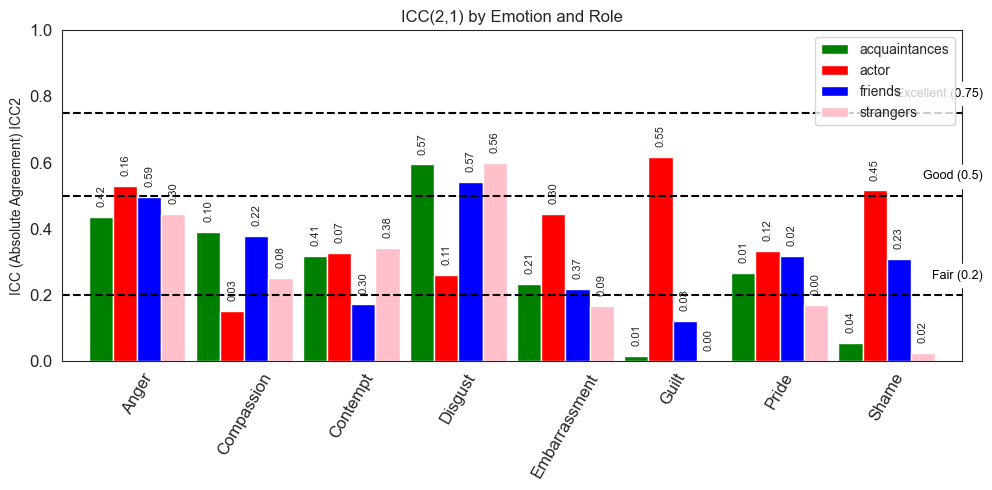

In [35]:
# Make the bar plot (with manual colors if you want)
role_colors = {
    'actor': 'red',
    'friends': 'blue',
    'acquaintances': 'green',
    'strangers': 'pink'
}
# Ensure the column order
icc_df = icc_df[[ 'acquaintances', 'actor', 'friends','strangers']]
prop_df = prop_df[icc_df.columns]
color_list = [role_colors[r] for r in icc_df.columns]

ax = icc_df.plot(kind='bar', width=0.9, ylim=(0,1), figsize=(10,5), color=color_list)
plt.ylabel('ICC (Absolute Agreement) ICC2')
plt.title('ICC(2,1) by Emotion and Role')

plt.axhline(0.2, color='black', linestyle='--')
plt.axhline(0.5, color='black', linestyle='--')
plt.axhline(0.75, color='black', linestyle='--')
plt.legend(loc='upper right')

n_emotions = len(icc_df.index)
n_roles = len(icc_df.columns)
bar_width = 0.9 / n_roles

for i, emotion in enumerate(icc_df.index):
    for j, role in enumerate(icc_df.columns):
        y = icc_df.loc[emotion, role]
        x = i - 0.45 + (j + 0.5) * bar_width
        prop = prop_df.loc[emotion, role]
        if pd.notnull(y):
            plt.text(x, y + 0.03, f"{prop:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

y_offsets = [0.04, 0.04, 0.04]
for (label, y, y_off) in zip(['Fair (0.2)', 'Good (0.5)', 'Excellent (0.75)'], [0.2, 0.5, 0.75], y_offsets):
    plt.text(n_emotions - 0.1, y + y_off, label, color='black', ha='right', va='bottom', fontsize=9, backgroundcolor='white')

plt.xticks(rotation=60, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

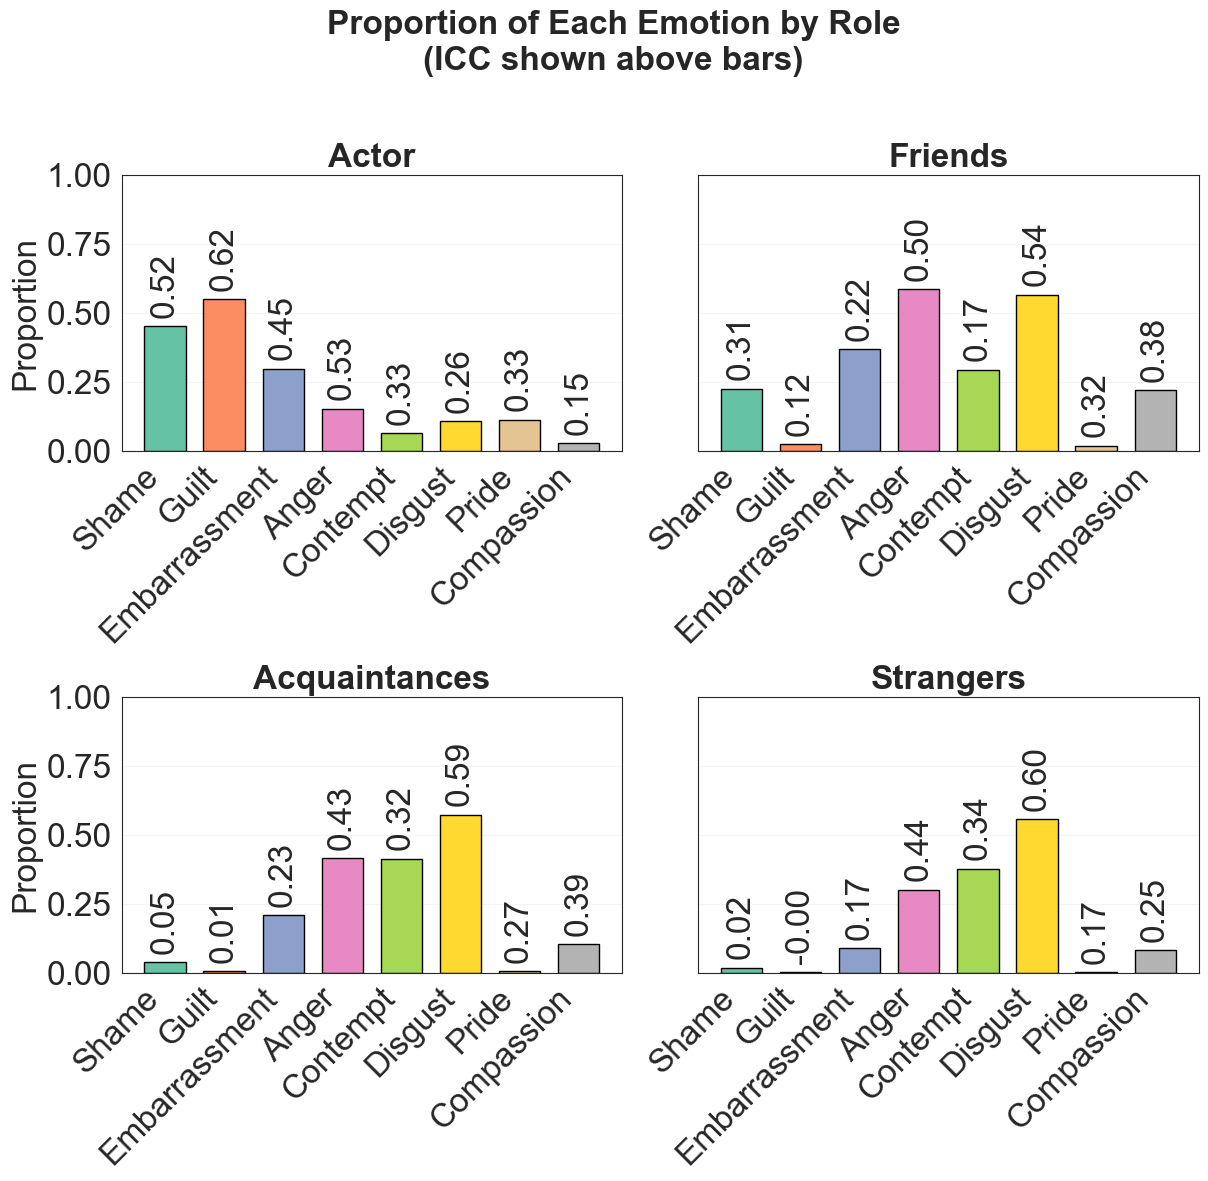

In [42]:
plot_emotion_panels(prop_df, icc_df=icc_df)

## Reaction

In [334]:
action_mapping = {
    "1": "Do nothing",
    "2": "Stay away or keep a distance from the actor",
    "3": "Gossip about / discuss with / complain to others informally",
    "4": "Verbal reprimand / verbal confrontation",
    "5": "Physical confrontation",
    "6": "Inform the authorities, such as the police",
    "7" : "Support the actor",
    "8": "Celebrate / praise"
}

In [335]:
# Reusable functions for action ICC analysis
def get_action_matrix(dfs, names, role, action_label, id_col, column_suffix='reaction'):
    """
    Extract reaction column and create binary matrix for a specific action.

    Parameters:
    - dfs: list of dataframes for each LLM
    - names: list of LLM names
    - role: role name ('friends', 'acquaintances', 'strangers')
    - action_label: specific action to measure (e.g., 'Do nothing', 'Stay away')
    - id_col: column name for ID
    - column_suffix: suffix for the column name ('reaction' or 'reaction_should')

    Returns:
    - matrix: dataframe with LLMs as columns, IDs as rows, binary values (1 if action chosen, 0 otherwise)
    """
    reaction_col = f"{role}_{column_suffix}"
    action_series = []

    # Get the numeric value for this action
    action_value = None
    for key, value in action_mapping.items():
        if value == action_label:
            action_value = key
            break

    if action_value is None:
        raise ValueError(f"Action '{action_label}' not found in action_mapping")

    for df, name in zip(dfs, names):
        if reaction_col in df.columns:
            # Extract the reaction column
            s = df.set_index(id_col)[reaction_col]

            # Handle case where s might be a DataFrame (due to duplicate columns)
            if isinstance(s, pd.DataFrame):
                s = s.iloc[:, 0]

            # Convert to numeric if needed
            if not pd.api.types.is_numeric_dtype(s):
                s = pd.to_numeric(s, errors='coerce')

            # Create binary series: 1 if this action was chosen, 0 otherwise
            s_binary = (s == int(action_value)).astype(int)
        else:
            # If column doesn't exist, create a Series of zeros
            s_binary = pd.Series(0, index=df[id_col], dtype=int)

        s_binary.name = name
        action_series.append(s_binary)

    # Concatenate all series into a matrix
    matrix = pd.concat(action_series, axis=1)
    return matrix

In [336]:
def build_action_matrices(dfs, names, roles, action_labels, id_col, column_suffix='reaction'):
    """
    Build action matrices for all roles and actions.

    Parameters:
    - dfs: list of dataframes for each LLM
    - names: list of LLM names
    - roles: list of role names
    - action_labels: list of action labels to analyze
    - id_col: column name for ID
    - column_suffix: suffix for the column name ('reaction' or 'reaction_should')

    Returns:
    - action_matrix: nested dict {role: {action: matrix}}
    """
    action_matrix = {role: {} for role in roles}

    print(f"\n{'='*60}")
    print(f"BUILDING ACTION MATRICES ({column_suffix.upper()})")
    print(f"{'='*60}")

    for role in roles:
        #print(f"\n{role.upper()} ROLE:")
        for action_label in action_labels:
            try:
                action_matrix[role][action_label] = get_action_matrix(dfs, names, role, action_label, id_col, column_suffix)
                matrix = action_matrix[role][action_label]
                #print(f"  {action_label}: {matrix.shape} - {matrix.sum().sum()} total choices")
            except Exception as e:
                print(f"  Error creating matrix for {role} - {action_label}: {e}")
                action_matrix[role][action_label] = None

    return action_matrix

In [337]:
def calculate_action_icc(action_matrix, roles, action_labels, id_col):
    """
    Calculate ICC for each action within each role.

    Parameters:
    - action_matrix: nested dict {role: {action: matrix}}
    - roles: list of role names
    - action_labels: list of action labels
    - id_col: column name for ID

    Returns:
    - ICC_results: nested dict with ICC results
    - ICC_visualise: nested dict with ICC values for visualization
    """
    ICC_results = {}
    ICC_visualise = {}

    print(f"\n{'='*60}")
    print("ICC CALCULATION FOR ACTIONS (BEHAVIORS)")
    print(f"{'='*60}")

    for role in roles:
        ICC_results[role] = {}
        ICC_visualise[role] = {}

        print(f"\n{role.upper()} ROLE:")
        for action_label in action_labels:
            if action_matrix[role][action_label] is not None:
                try:
                    # Check if we have enough data for ICC calculation
                    matrix = action_matrix[role][action_label]
                    if matrix.shape[1] < 2:
                        print(f"  {action_label}: Only {matrix.shape[1]} LLM(s), skipping ICC")
                        ICC_results[role][action_label] = None
                        ICC_visualise[role][action_label] = None
                        continue

                    # Check if there's enough variation (not all 0s or all 1s)
                    total_choices = matrix.sum().sum()
                    total_possible = matrix.shape[0] * matrix.shape[1]
                    if total_choices == 0:
                        print(f"  {action_label}: No choices made, skipping ICC")
                        ICC_results[role][action_label] = None
                        ICC_visualise[role][action_label] = None
                        continue
                    elif total_choices == total_possible:
                        print(f"  {action_label}: All LLMs chose this action, skipping ICC")
                        ICC_results[role][action_label] = None
                        ICC_visualise[role][action_label] = None
                        continue

                    icc_df = get_ICC(matrix, id_col)
                    ICC_results[role][action_label] = icc_df
                    ICC_visualise[role][action_label] = icc_df['ICC'].values[0]

                    # Interpret ICC value
                    icc_val = icc_df['ICC'].values[0]
                    if icc_val >= 0.75:
                        interpretation = "Excellent"
                    elif icc_val >= 0.5:
                        interpretation = "Good"
                    elif icc_val >= 0.2:
                        interpretation = "Fair"
                    else:
                        interpretation = "Poor"

                    choice_rate = total_choices / total_possible
                    print(f"  {action_label}: ICC = {icc_val:.3f} ({interpretation}), Choice rate = {choice_rate:.3f}")

                except Exception as e:
                    print(f"  Error calculating ICC for {role} - {action_label}: {e}")
                    ICC_results[role][action_label] = None
                    ICC_visualise[role][action_label] = None
            else:
                print(f"  {action_label}: Matrix creation failed")
                ICC_results[role][action_label] = None
                ICC_visualise[role][action_label] = None

    return ICC_results, ICC_visualise

In [338]:
def calculate_action_proportions(action_matrix, roles, action_labels):
    """
    Calculate proportion of choices for each action within each role.

    Parameters:
    - action_matrix: nested dict {role: {action: matrix}}
    - roles: list of role names
    - action_labels: list of action labels

    Returns:
    - prop_actions: nested dict with proportions
    """
    prop_actions = {}
    for role in roles:
        prop_actions[role] = {}
        for action_label in action_labels:
            if action_matrix[role][action_label] is not None:
                matrix = action_matrix[role][action_label]
                total_choices = matrix.sum().sum()
                total_possible = matrix.shape[0] * matrix.shape[1]
                if total_possible > 0:
                    prop = total_choices / total_possible
                else:
                    prop = 0
                prop_actions[role][action_label] = prop
            else:
                prop_actions[role][action_label] = 0

    return prop_actions

In [339]:
def plot_action_icc(ICC_visualise, prop_actions, roles, action_labels, title_suffix=""):
    """
    Create visualization for action ICC - similar to emotions plot.

    Parameters:
    - ICC_visualise: nested dict with ICC values
    - prop_actions: nested dict with proportions
    - roles: list of role names
    - action_labels: list of action labels
    - title_suffix: additional text for the title
    """
    # Step 1: Create DataFrame from ICC_visualise
    icc_df_actions = pd.DataFrame(ICC_visualise)  # rows = actions, columns = roles

    # Step 2: Create proportion DataFrame
    prop_df_actions = pd.DataFrame(prop_actions)

    # Step 3: Shorten action labels for better display
    action_short_names = {
        'Do nothing': 'Do nothing',
        'Stay away or keep a distance from the actor': 'Stay away',
        'Gossip about / discuss with / complain to others informally': 'Gossip',
        'Verbal reprimand / verbal confrontation': 'Verbal reprimand',
        'Physical confrontation': 'Physical confrontation',
        'Inform the authorities, such as the police': 'Inform authorities',
        'Support the actor': 'Support actor',
        'Celebrate / praise': 'Celebrate'
    }

    # Rename index with shorter names
    icc_df_actions.index = [action_short_names.get(action, action) for action in icc_df_actions.index]
    prop_df_actions.index = [action_short_names.get(action, action) for action in prop_df_actions.index]

    # Step 4: Make the bar plot
    role_colors = {
        'friends': 'blue',
        'acquaintances': 'green',
        'strangers': 'pink'
    }

    # Ensure the column order
    icc_df_actions = icc_df_actions[roles]
    prop_df_actions = prop_df_actions[icc_df_actions.columns]
    color_list = [role_colors[r] for r in icc_df_actions.columns]

    ax = icc_df_actions.plot(kind='bar', width=0.9, ylim=(0,1), figsize=(14,7), color=color_list)
    plt.ylabel('ICC (Absolute Agreement) ICC2', fontsize=12)
    plt.title(f'ICC(2,1) by Action and Role{title_suffix}\n(Measures LLM agreement on behavioral choices)', fontsize=14)

    plt.axhline(0.2, color='black', linestyle='--', alpha=0.5)
    plt.axhline(0.5, color='black', linestyle='--', alpha=0.5)
    plt.axhline(0.75, color='black', linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    n_actions = len(icc_df_actions.index)
    n_roles = len(icc_df_actions.columns)
    bar_width = 0.9 / n_roles

    # Add proportion text on bars
    for i, action in enumerate(icc_df_actions.index):
        for j, role in enumerate(icc_df_actions.columns):
            y = icc_df_actions.loc[action, role]
            x = i - 0.45 + (j + 0.5) * bar_width
            prop = prop_df_actions.loc[action, role]
            if pd.notnull(y):
                plt.text(x, y + 0.03, f"{prop:.3f}", ha='center', va='bottom', fontsize=8, rotation=90)

    # Add reference line labels
    y_offsets = [0.04, 0.04, 0.04]
    for (label, y, y_off) in zip(['Fair (0.2)', 'Good (0.5)', 'Excellent (0.75)'], [0.2, 0.5, 0.75], y_offsets):
        plt.text(n_actions - 0.1, y + y_off, label, color='black', ha='right', va='bottom', fontsize=9, backgroundcolor='white')

    # Fix x-axis labels with better alignment
    plt.xticks(rotation=45, fontsize=12, ha='right')
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

In [340]:
def print_action_summary(ICC_visualise, prop_actions, roles, action_labels):
    """
    Print a summary of action ICC results.

    Parameters:
    - ICC_visualise: nested dict with ICC values
    - prop_actions: nested dict with proportions
    - roles: list of role names
    - action_labels: list of action labels
    """
    print(f"\n{'='*60}")
    print("ACTION ICC SUMMARY")
    print(f"{'='*60}")
    for role in roles:
        print(f"\n{role.upper()}:")
        for action_label in action_labels:
            icc_val = ICC_visualise[role][action_label]
            prop_val = prop_actions[role][action_label]
            if icc_val is not None:
                # Get interpretation
                if icc_val >= 0.75:
                    interp = "Excellent"
                elif icc_val >= 0.5:
                    interp = "Good"
                elif icc_val >= 0.2:
                    interp = "Fair"
                else:
                    interp = "Poor"

                print(f"  {action_label}: ICC = {icc_val:.3f} ({interp}), Choice rate = {prop_val:.3f}")
            else:
                print(f"  {action_label}: ICC = N/A, Choice rate = {prop_val:.3f}")

In [341]:
# Define parameters
reaction_roles = ['friends', 'acquaintances', 'strangers']
action_labels = list(action_mapping.values())

### Would



ANALYZING REACTION_SHOULD (What people should do)

BUILDING ACTION MATRICES (REACTION)

ICC CALCULATION FOR ACTIONS (BEHAVIORS)

FRIENDS ROLE:
  Do nothing: ICC = 0.346 (Fair), Choice rate = 0.097
  Stay away or keep a distance from the actor: ICC = 0.012 (Poor), Choice rate = 0.015
  Gossip about / discuss with / complain to others informally: ICC = 0.143 (Poor), Choice rate = 0.376
  Verbal reprimand / verbal confrontation: ICC = 0.221 (Fair), Choice rate = 0.382
  Physical confrontation: No choices made, skipping ICC
  Inform the authorities, such as the police: ICC = 0.377 (Fair), Choice rate = 0.032
  Support the actor: ICC = 0.450 (Fair), Choice rate = 0.097
  Celebrate / praise: ICC = 0.150 (Poor), Choice rate = 0.001

ACQUAINTANCES ROLE:
  Do nothing: ICC = 0.437 (Fair), Choice rate = 0.192
  Stay away or keep a distance from the actor: ICC = 0.077 (Poor), Choice rate = 0.025
  Gossip about / discuss with / complain to others informally: ICC = 0.417 (Fair), Choice rate = 0.72

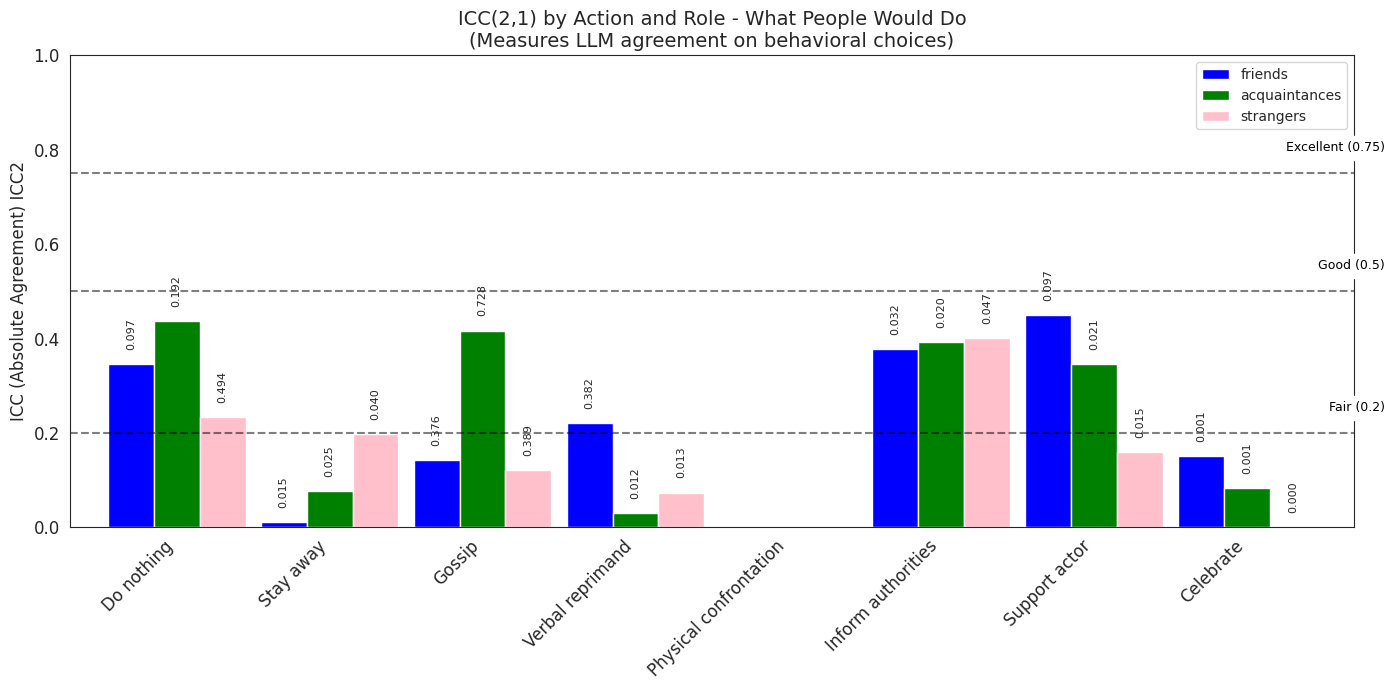

/tmp/ipython-input-1895831357.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prop_df_actions.index, rotation=45, ha='right', fontsize=10)
/tmp/ipython-input-1895831357.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prop_df_actions.index, rotation=45, ha='right', fontsize=10)
/tmp/ipython-input-1895831357.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prop_df_actions.index, rotation=45, ha='right', fontsize=10)


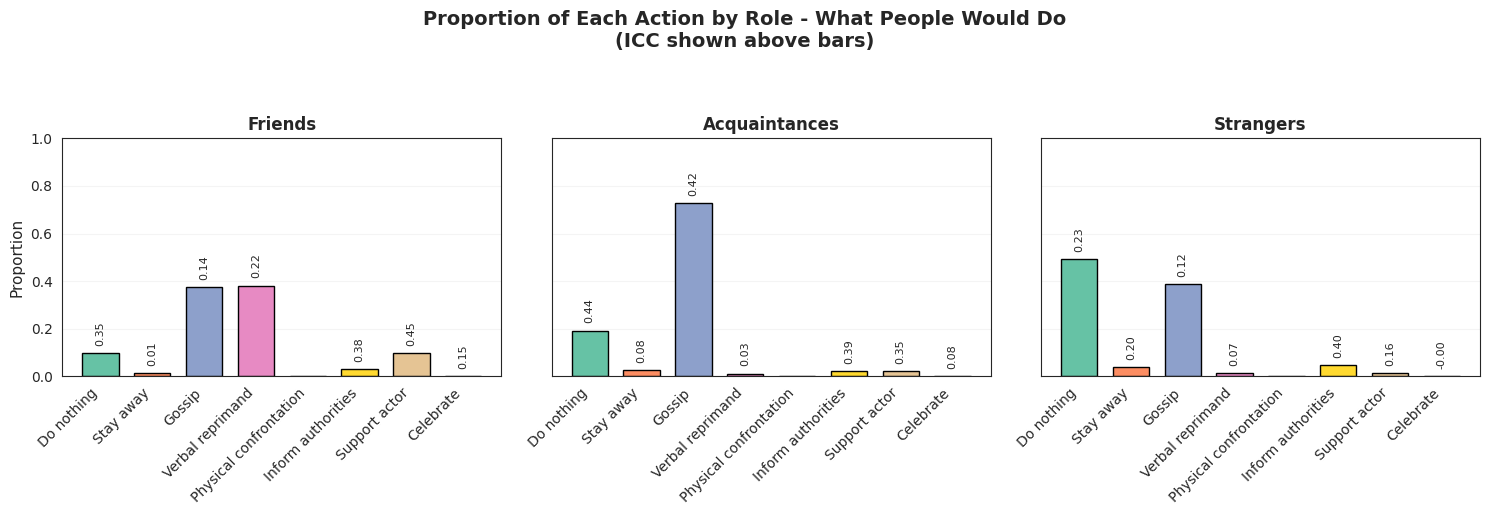

In [342]:
# Analyze reaction_should (what people would do)
print("\n\nANALYZING REACTION_SHOULD (What people should do)")
print("="*50)

# Build matrices for "would" columns
action_matrix = build_action_matrices(dfs, names, reaction_roles, action_labels, id_col, 'reaction')

# Calculate ICC
ICC_results, ICC_visualise = calculate_action_icc(action_matrix, reaction_roles, action_labels, id_col)

# Calculate proportions
prop_actions = calculate_action_proportions(action_matrix, reaction_roles, action_labels)

# Visualize
plot_action_icc(ICC_visualise, prop_actions, reaction_roles, action_labels, " - What People Would Do")
plot_action_panels(prop_actions, ICC_visualise, title_suffix="- What People Would Do")

### Should



ANALYZING REACTION_SHOULD (What people should do)

BUILDING ACTION MATRICES (REACTION_SHOULD)

ICC CALCULATION FOR ACTIONS (BEHAVIORS)

FRIENDS ROLE:
  Do nothing: ICC = 0.326 (Fair), Choice rate = 0.109
  Stay away or keep a distance from the actor: ICC = 0.006 (Poor), Choice rate = 0.007
  Gossip about / discuss with / complain to others informally: ICC = 0.017 (Poor), Choice rate = 0.115
  Verbal reprimand / verbal confrontation: ICC = 0.302 (Fair), Choice rate = 0.587
  Physical confrontation: No choices made, skipping ICC
  Inform the authorities, such as the police: ICC = 0.418 (Fair), Choice rate = 0.048
  Support the actor: ICC = 0.417 (Fair), Choice rate = 0.133
  Celebrate / praise: ICC = 0.199 (Poor), Choice rate = 0.001

ACQUAINTANCES ROLE:
  Do nothing: ICC = 0.341 (Fair), Choice rate = 0.286
  Stay away or keep a distance from the actor: ICC = 0.090 (Poor), Choice rate = 0.039
  Gossip about / discuss with / complain to others informally: ICC = 0.160 (Poor), Choice rate

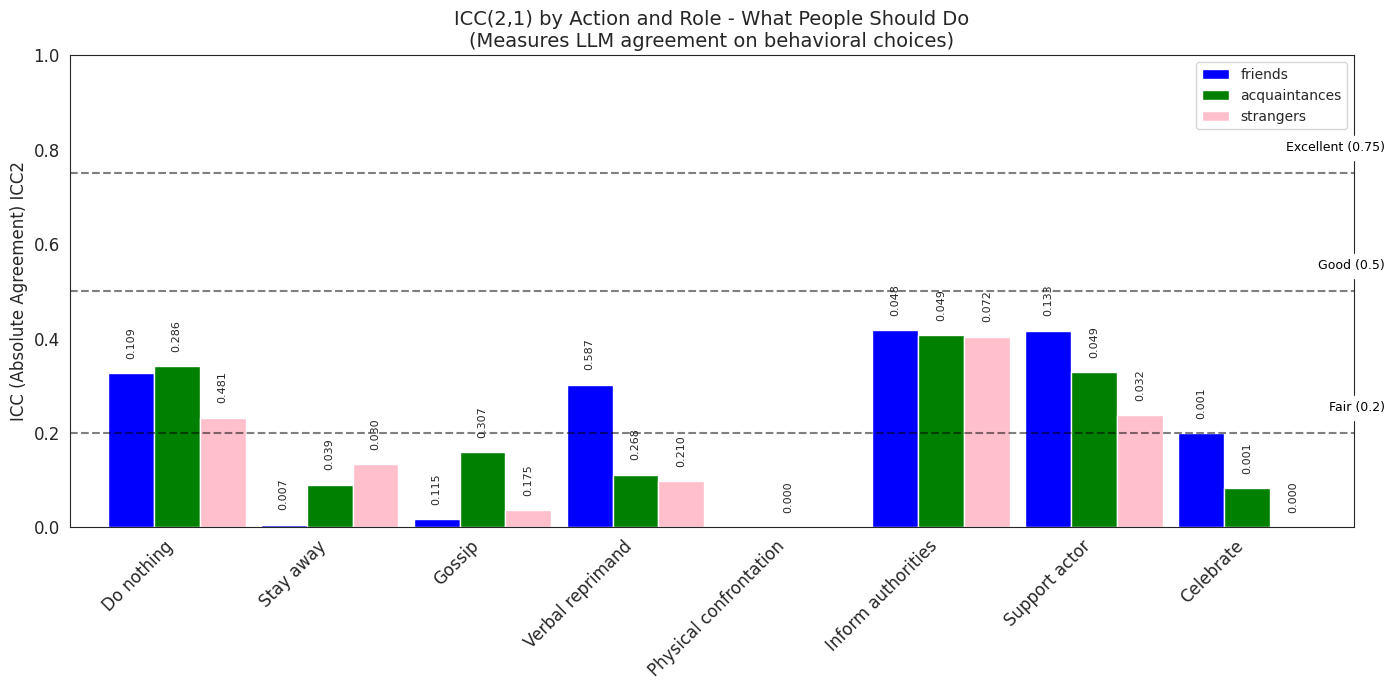

/tmp/ipython-input-1895831357.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prop_df_actions.index, rotation=45, ha='right', fontsize=10)
/tmp/ipython-input-1895831357.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prop_df_actions.index, rotation=45, ha='right', fontsize=10)
/tmp/ipython-input-1895831357.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prop_df_actions.index, rotation=45, ha='right', fontsize=10)


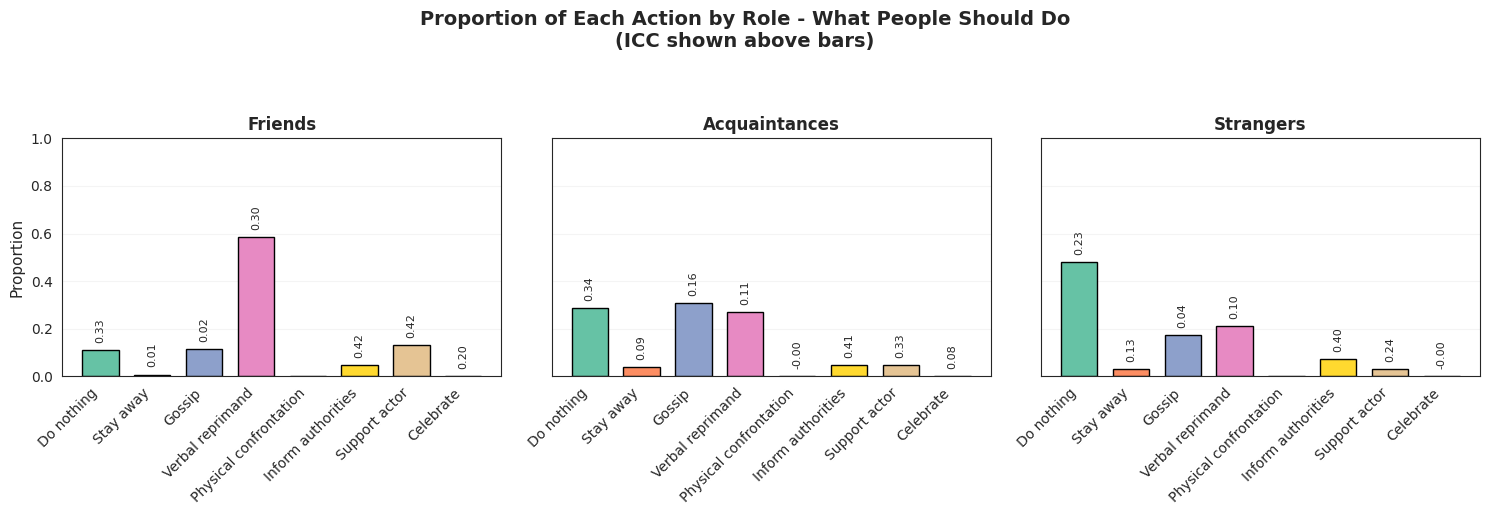

In [343]:
# Analyze reaction_should (what people should do)
print("\n\nANALYZING REACTION_SHOULD (What people should do)")
print("="*50)

# Build matrices for "would" columns
action_matrix_should = build_action_matrices(dfs, names, reaction_roles, action_labels, id_col, 'reaction_should')

# Calculate ICC
ICC_results_should, ICC_visualise_should = calculate_action_icc(action_matrix_should, reaction_roles, action_labels, id_col)

# Calculate proportions
prop_actions_should = calculate_action_proportions(action_matrix_should, reaction_roles, action_labels)

# Visualize
plot_action_icc(ICC_visualise_should, prop_actions_should, reaction_roles, action_labels, " - What People Should Do")
plot_action_panels(prop_actions_should, ICC_visualise_should, title_suffix="- What People Should Do")

# LLM Direct Enforcement Plots

In [344]:
df_direct = pd.read_csv(folder_path+'gpt_humanness_responses.csv')
df_direct

,ID,actor,stimuli,actor_gender,llm_expressed_emotions,llm_emotion_strength,llm_response_action,user_behavior_inappropriateness,user_behavior_wrongness,input_tokens,output_tokens,total_tokens
0,1,William,William did not tell someone's girlfriend that...,male,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 3.0}",3,4,4,834,1280,2114
1,1,Maria,Maria did not tell someone's girlfriend that h...,female,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 2.0}",4,2,2,834,1088,1922
2,2,John,John rarely talks to his elderly roommates and...,male,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 2.0}",3,2,2,843,1344,2187
3,2,Mary,Mary rarely talks to her elderly roommates and...,female,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 2.0}",4,2,2,843,1024,1867
4,3,Robert,Robert stayed up until 5 am because he assumed...,male,"{'emotions': ['Compassion'], 'no_emotion': Fal...",{'Compassion': 2.0},4,2,2,841,954,1795
...,...,...,...,...,...,...,...,...,...,...,...,...
897,449,Richard,Richard reads things in a British accent even ...,male,"{'emotions': [], 'no_emotion': True, 'other_em...",NaN,2,1,1,834,436,1270
898,450,Elizabeth,Elizabeth touched a passed-out guy inappropria...,female,"{'emotions': ['Disgust', 'Compassion'], 'no_em...","{'Compassion': 3.0, 'Concern': 4.0, 'Disgust':...",4,5,5,832,1800,2632
899,450,Charles,Charles touched a passed-out girl inappropriat...,male,"{'emotions': ['Disgust', 'Anger', 'Compassion'...","{'Anger': 3.0, 'Compassion': 2.0, 'Disgust': 4.0}",4,5,5,832,1162,1994
900,451,Linda,Linda smells her socks and underwear every tim...,female,"{'emotions': ['Compassion'], 'no_emotion': Fal...",{'Compassion': 2.0},2,1,1,840,954,1794


In [345]:
for col in ['llm_expressed_emotions', 'llm_emotion_strength']:
    df_direct[col] = df_direct[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)

df_direct = df_direct.rename(columns={'actor_gender': 'gender'})

In [346]:
# Select only the relevant metadata columns
meta = df[["ID", "MFT", "rot-agree", "action-agree", "action-pressure", "action-hypothetical"]]

# Merge each model dataframe with the metadata
df_direct  = df_direct.merge(meta, on="ID", how="inner")
df_direct = df_direct.rename(columns={'actor_gender': 'gender'})
df_direct

,ID,actor,stimuli,gender,llm_expressed_emotions,llm_emotion_strength,llm_response_action,user_behavior_inappropriateness,user_behavior_wrongness,input_tokens,output_tokens,total_tokens,MFT,rot-agree,action-agree,action-pressure,action-hypothetical
0,1,William,William did not tell someone's girlfriend that...,male,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 3.0}",3,4,4,834,1280,2114,care-harm,4,4,2,explicit-no
1,1,Maria,Maria did not tell someone's girlfriend that h...,female,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 2.0}",4,2,2,834,1088,1922,care-harm,4,4,2,explicit-no
2,2,John,John rarely talks to his elderly roommates and...,male,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 2.0}",3,2,2,843,1344,2187,care-harm,3,3,1,explicit-no
3,2,Mary,Mary rarely talks to her elderly roommates and...,female,"{'emotions': ['Compassion'], 'no_emotion': Fal...","{'Compassion': 3.0, 'Concern': 2.0}",4,2,2,843,1024,1867,care-harm,3,3,1,explicit-no
4,3,Robert,Robert stayed up until 5 am because he assumed...,male,"{'emotions': ['Compassion'], 'no_emotion': Fal...",{'Compassion': 2.0},4,2,2,841,954,1795,care-harm,3,2,0,hypothetical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,449,Richard,Richard reads things in a British accent even ...,male,"{'emotions': [], 'no_emotion': True, 'other_em...",NaN,2,1,1,834,436,1270,sancticity-degradation,2,2,-1,explicit
898,450,Elizabeth,Elizabeth touched a passed-out guy inappropria...,female,"{'emotions': ['Disgust', 'Compassion'], 'no_em...","{'Compassion': 3.0, 'Concern': 4.0, 'Disgust':...",4,5,5,832,1800,2632,sancticity-degradation,4,4,-2,explicit
899,450,Charles,Charles touched a passed-out girl inappropriat...,male,"{'emotions': ['Disgust', 'Anger', 'Compassion'...","{'Anger': 3.0, 'Compassion': 2.0, 'Disgust': 4.0}",4,5,5,832,1162,1994,sancticity-degradation,4,4,-2,explicit
900,451,Linda,Linda smells her socks and underwear every tim...,female,"{'emotions': ['Compassion'], 'no_emotion': Fal...",{'Compassion': 2.0},2,1,1,840,954,1794,sancticity-degradation,2,2,0,explicit


In [347]:
df_llm = expand_strengths(df_direct, 'llm_emotion_strength', actor_label='llm', observer_label='GPT')
df_llm = df_llm.drop(columns=["actor"])
df_llm = df_llm.merge(df_direct[["ID","MFT"]], on="ID", how="inner")
df_llm

,ID,gender,observer,emotion,strength,MFT
0,1,male,GPT,Compassion,3.0,care-harm
1,1,male,GPT,Compassion,3.0,care-harm
2,1,male,GPT,Concern,3.0,care-harm
3,1,male,GPT,Concern,3.0,care-harm
4,1,female,GPT,Compassion,3.0,care-harm
...,...,...,...,...,...,...
3089,450,male,GPT,Disgust,4.0,sancticity-degradation
3090,451,female,GPT,Compassion,2.0,sancticity-degradation
3091,451,female,GPT,Compassion,2.0,sancticity-degradation
3092,451,male,GPT,Compassion,2.0,sancticity-degradation


## Emotion Proportions

In [348]:
def summarize_emotion_strengths(df, strength_col='llm_emotion_strength'):
    """
    Expand emotion strength dicts and compute mean ± SE per emotion.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a column of emotion strength dicts.
    strength_col : str
        Column containing dicts like {'Compassion': 3.0, 'Disgust': 4.0}

    Returns
    -------
    summary_df : pd.DataFrame
        Columns: ['emotion', 'mean', 'se', 'n']
    """
    # Extract strength dicts (skip NaN)
    valid = df[strength_col].dropna()

    # Flatten all emotion-strength pairs
    rows = []
    for d in valid:
        if isinstance(d, dict):
            for emo, val in d.items():
                if pd.notnull(val):
                    rows.append({'emotion': emo, 'strength': float(val)})

    if not rows:
        raise ValueError("No valid emotion strength data found.")

    emo_df = pd.DataFrame(rows)

    # Compute mean and SE per emotion
    summary = (
        emo_df.groupby('emotion')['strength']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    summary['se'] = summary['std'] / np.sqrt(summary['count'])
    summary = summary[['emotion', 'mean', 'se', 'count']]
    return summary.sort_values('mean', ascending=False)

In [349]:
def plot_selected_emotion_proportions_with_strengths(summary_df):
    """
    Plot proportions of selected emotions with mean ± SE strength annotations.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Must contain columns: ['emotion', 'mean', 'se', 'count']
    """

    # Define the focus emotions
    selected_emotions = [
        'Shame', 'Guilt', 'Embarrassment', 'Anger', 'Contempt', 'Disgust', 'Pride', 'Compassion', 'Concern'
    ]

    # Filter for selected emotions only (case-insensitive)
    df = summary_df[summary_df['emotion'].str.capitalize().isin(selected_emotions)].copy()

    # Handle possible missing emotions
    df['emotion'] = pd.Categorical(df['emotion'], categories=selected_emotions, ordered=True)
    df = df.sort_values('emotion').reset_index(drop=True)

    # Compute proportions
    total_count = df['count'].sum()
    df['proportion'] = df['count'] / total_count

    # Replace NaN/inf with 0 for safety
    df[['mean', 'se', 'proportion']] = df[['mean', 'se', 'proportion']].replace([np.nan, np.inf, -np.inf], 0)

    # --- Plot setup ---
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [plt.cm.tab10(i % 10) for i in range(len(df))]

    # --- Bar plot of proportions ---
    bars = ax.bar(
        df['emotion'],
        df['proportion'],
        color=colors,
        edgecolor='black'
    )

    # --- Add mean ± SE annotations ---
    for bar, (_, row) in zip(bars, df.iterrows()):
      text = f"{row['mean']:.2f}±{row['se']:.2f}"
      ax.text(
          bar.get_x() + bar.get_width() / 2,
          bar.get_height() + 0.003,  # small vertical gap
          text,
          ha='center',
          va='bottom',
          fontsize=8,
          rotation=0    # horizontal text
      )

    # --- Formatting ---
    ax.set_ylabel('Proportion of Emotion', fontsize=11, fontweight='bold')
    ax.set_xlabel('Emotion', fontsize=11, fontweight='bold')
    ax.set_title('Distribution of Key Emotions\n(Proportion with Mean ± SE Strength)', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim(0, df['proportion'].max() * 1.25)
    ax.set_xticklabels(df['emotion'], ha='center', fontsize=10)
    ax.grid(alpha=0.3, axis='y')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-1793429580.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['emotion'], ha='center', fontsize=10)


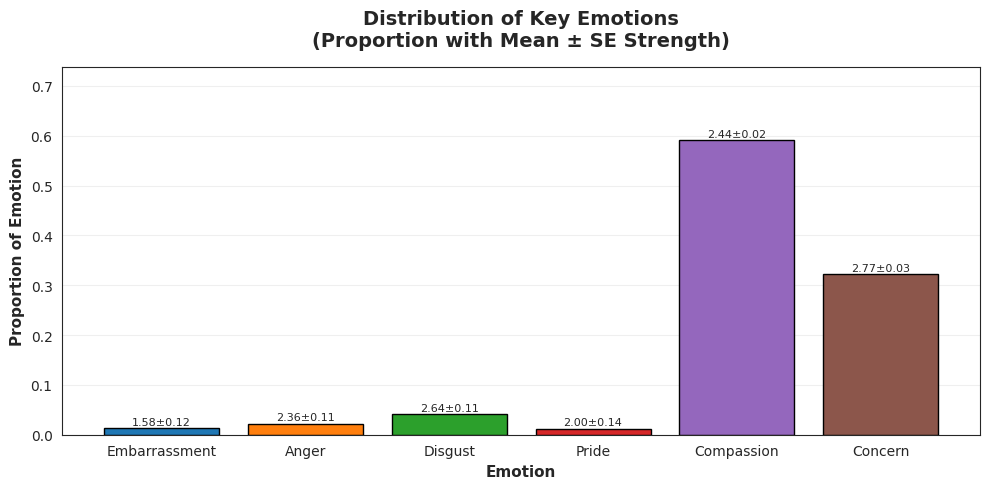

In [350]:
summary_df = summarize_emotion_strengths(df_direct)
plot_selected_emotion_proportions_with_strengths(summary_df)

## Action Proportions

In [351]:
ACTIONS = {
    1: "Ignore the behavior",
    2: "Express approval",
    3: "Express disapproval",
    4: "Warn about consequences",
    5: "Flag the user for inappropriate content"
}

In [352]:
def plot_action_proportions(df, action_col='llm_response_action'):
    """
    Plot proportions of each possible action in ACTIONS (including zero-count actions),
    automatically handling numeric or string-encoded action values.
    X-axis labels are displayed on two lines for readability.
    """

    # Define possible actions (with line breaks for 2-line labels)
    ACTIONS = {
        1: "Ignore\nthe behavior",
        2: "Express\napproval",
        3: "Express\ndisapproval",
        4: "Warn about\nconsequences",
        5: "Flag the user for\ninappropriate content"
    }

    # --- Convert action column to integers (safe conversion) ---
    df = df.copy()
    df[action_col] = pd.to_numeric(df[action_col], errors='coerce').astype('Int64')

    # --- Count occurrences ---
    counts = df[action_col].value_counts(dropna=False).reindex(ACTIONS.keys(), fill_value=0)

    # --- Compute proportions ---
    total = counts.sum()
    proportions = counts / total if total > 0 else counts

    # --- Build plotting DataFrame ---
    plot_df = pd.DataFrame({
        "action_id": ACTIONS.keys(),
        "action_label": ACTIONS.values(),
        "count": counts.values,
        "proportion": proportions.values
    })

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        plot_df["action_label"],
        plot_df["proportion"],
        color=plt.cm.tab10.colors[:len(plot_df)],
        edgecolor='black'
    )

    # --- Add labels above bars ---
    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{int(row['count'])} ({row['proportion']*100:.1f}%)",
            ha='center', va='bottom',
            fontsize=8
        )

    # --- Formatting ---
    ax.set_ylabel('Proportion of Actions', fontsize=11, fontweight='bold')
    ax.set_xlabel('Action Type', fontsize=11, fontweight='bold')
    ax.set_title('Distribution of LLM Response Actions', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim(0, plot_df["proportion"].max() * 1.25 if plot_df["proportion"].max() > 0 else 0.1)

    # Multi-line labels: rotation=0 keeps them stacked neatly
    ax.set_xticklabels(plot_df["action_label"], rotation=0, ha='center', fontsize=10)
    ax.grid(alpha=0.3, axis='y')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-26898019.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["action_label"], rotation=0, ha='center', fontsize=10)


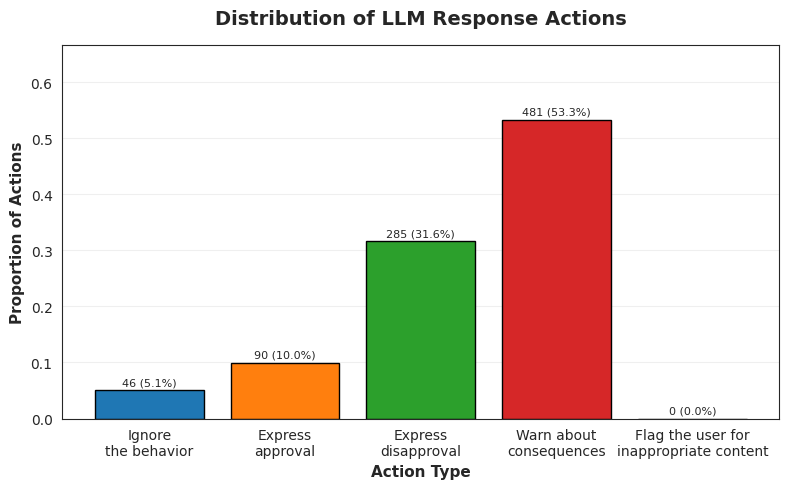

In [353]:
plot_action_proportions(df_direct, action_col='llm_response_action')

## Appropriateness-Wrongness

/tmp/ipython-input-1043066952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1043066952.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


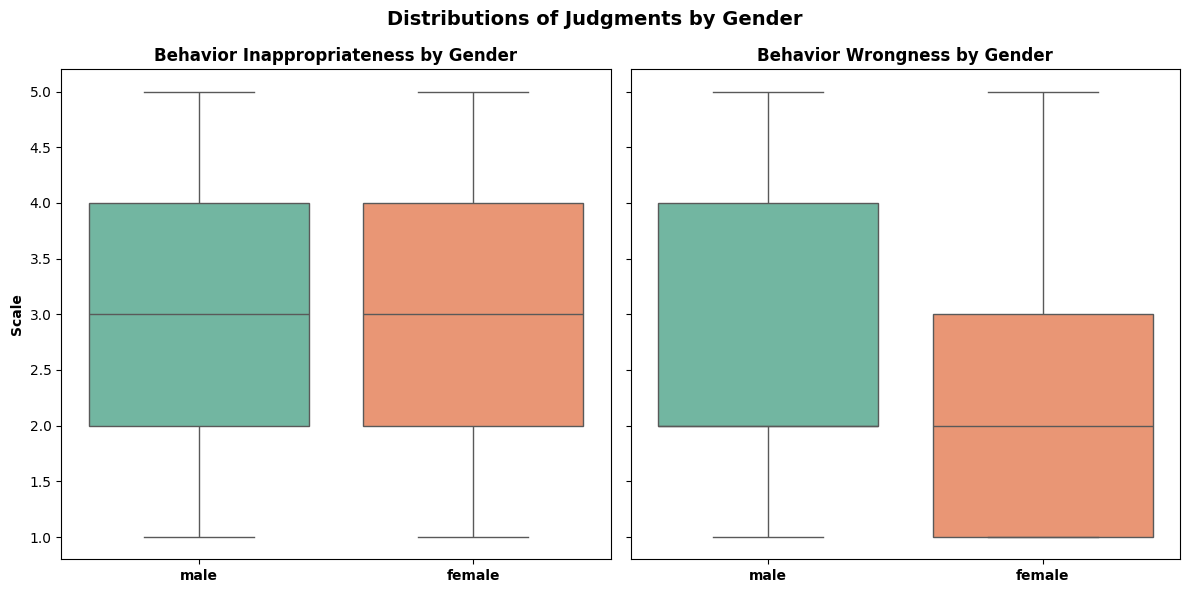

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,6), sharey=True)

# Boxplot: Inappropriateness
sns.boxplot(
    data=df_direct,
    x="gender", y="user_behavior_inappropriateness",
    palette="Set2", ax=axes[0]
)
axes[0].set_title("Behavior Inappropriateness by Gender", fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Scale", fontweight='bold')

# Boxplot: Wrongness
sns.boxplot(
    data=df_direct,
    x="gender", y="user_behavior_wrongness",
    palette="Set2", ax=axes[1]
)
axes[1].set_title("Behavior Wrongness by Gender", fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("Wrongness")

# --- Make x-axis labels (male/female) bold ---
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')

plt.suptitle("Distributions of Judgments by Gender", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

## Overall Emotion-Gender differences

In [354]:
agg_df_human = aggregate_emotions(df_llm, ["observer", "gender", "emotion"])
agg_df_human

,observer,gender,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,GPT,female,Alarm,2,4.000000,0.000000,4.000000,4.000000
1,GPT,female,Anger,22,2.363636,0.657952,2.071917,2.655356
2,GPT,female,Compassion,882,2.476190,0.567768,2.438669,2.513712
3,GPT,female,Concern,472,2.720339,0.595604,2.666468,2.774210
4,GPT,female,Disappointment,30,2.266667,0.449776,2.098717,2.434616
5,GPT,female,Disapproval,4,3.500000,0.577350,2.581307,4.418693
6,GPT,female,Disgust,50,2.520000,0.814160,2.288618,2.751382
7,GPT,female,Embarrassment,8,1.750000,0.462910,1.362998,2.137002
8,GPT,female,Pride,18,2.111111,0.582983,1.821200,2.401022
9,GPT,female,Sadness,6,2.333333,0.516398,1.791407,2.875260


/tmp/ipython-input-378739145.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipython-input-378739145.py:27: UserWarning: The palette list has more values (14) than needed (11), which may not be intended.
  bars = sns.barplot(
/tmp/ipython-input-378739145.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipython-input-378739145.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipython-input-378739145.py:27: UserWarning: The palette list has more values (14) than needed (12), which may not be intended.
  bars = sns.barplot(
/tm

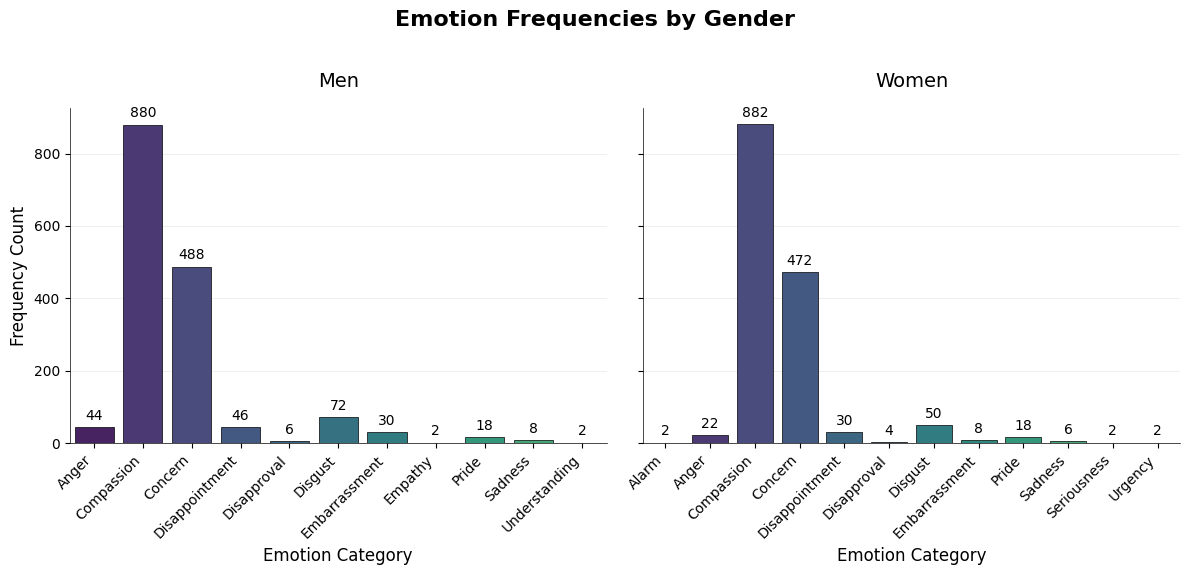

<Figure size 640x480 with 0 Axes>

In [355]:
agg_df_human["gender"] = agg_df_human["gender"].replace({
    "male": "men",
    "female": "women"
})

# Filter data for GPT observations only
df_gpt = agg_df_human[agg_df_human["observer"] == "GPT"].copy()

# Set publication-ready style
plt.style.use('default')
sns.set_palette("viridis")

# Create figure with appropriate size for publication
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
fig.suptitle("Emotion Frequencies by Gender",
             fontsize=16, fontweight='bold', y=0.95)

# Define colors for consistency
colors = sns.color_palette("viridis", n_colors=len(df_gpt["emotion"].unique()))

# Plot for each gender
for idx, (ax, gender) in enumerate(zip(axes, ["men", "women"])):
    # Filter data for current gender
    gender_data = df_gpt[df_gpt["gender"] == gender]

    # Create bar plot
    bars = sns.barplot(
        data=gender_data,
        x="emotion",
        y="frequency",
        palette=colors,
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    # Add value annotations on bars
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                xy=(bar.get_x() + bar.get_width()/2., height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='medium'
            )

    # Customize subplot appearance
    ax.set_title(f'{gender.capitalize()}',
                fontsize=14, fontweight='medium', pad=15)
    ax.set_xlabel('Emotion Category', fontsize=12, fontweight='medium')

    # Set y-label only for left subplot
    if idx == 0:
        ax.set_ylabel('Frequency Count', fontsize=12, fontweight='medium')
    else:
        ax.set_ylabel('')

    # Rotate x-tick labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(),
                      rotation=45,
                      ha='right',
                      fontsize=10)

    # Customize grid and spines
    ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)

    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

# Adjust layout to prevent label cutoff
plt.tight_layout(rect=[0, 0, 1, 0.93])

# Add subtle background color for better print quality
fig.patch.set_facecolor('white')

# Display the plot
plt.show()

# Optional: Save figure in high resolution for publication
plt.savefig('emotion_frequencies_by_gender.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')

/tmp/ipython-input-1473151626.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


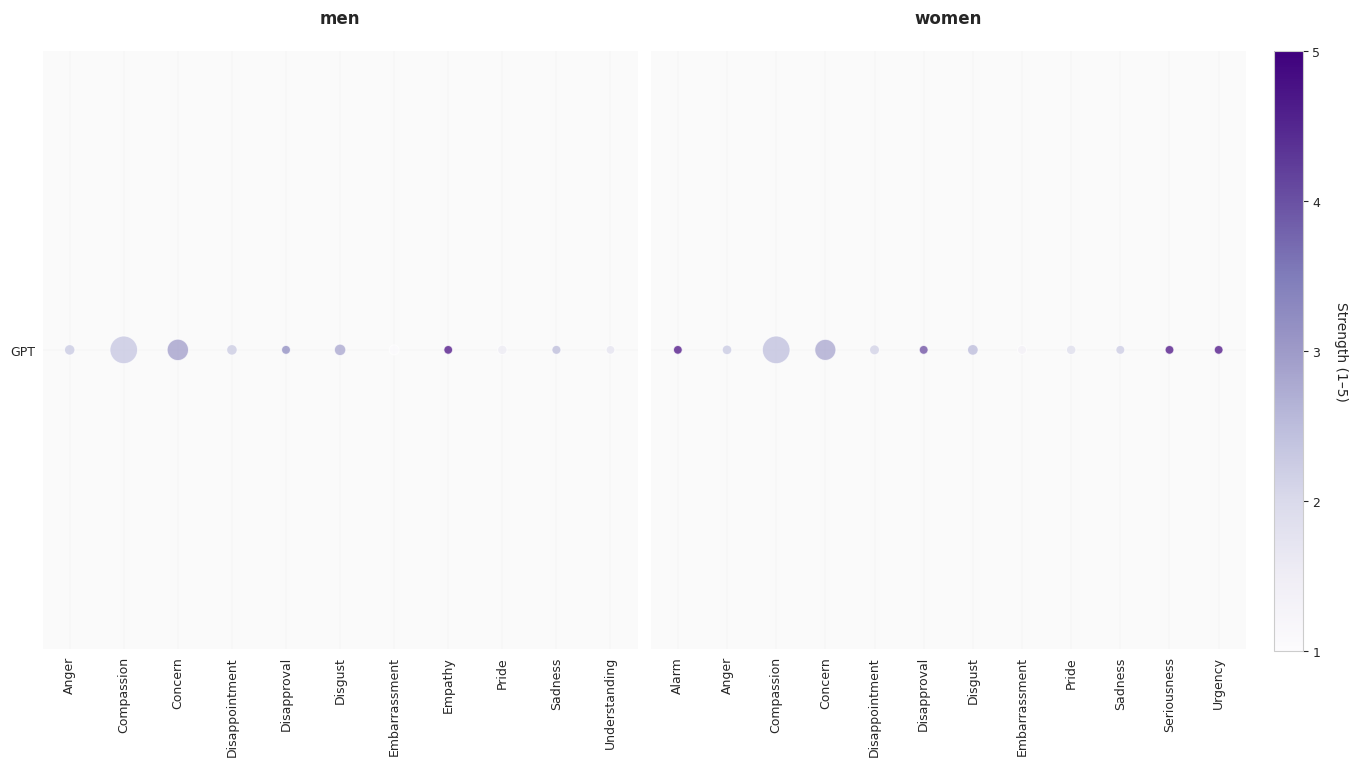

In [356]:
plot_bubble(agg_df_human, "gender", "observer", plt_type='gpt_humanness', palette="Purples")

## Moral Dimensions

In [357]:
agg_mft_gpt = aggregate_emotions(df_llm, ["MFT", "gender", "emotion"])
agg_mft_gpt

,MFT,gender,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,authority-subversion,female,Anger,4,2.000000,0.000000,2.000000,2.000000
1,authority-subversion,female,Compassion,172,2.383721,0.555011,2.300186,2.467256
2,authority-subversion,female,Concern,98,2.530612,0.541172,2.422114,2.639110
3,authority-subversion,female,Disappointment,2,2.000000,0.000000,2.000000,2.000000
4,authority-subversion,female,Disgust,4,2.500000,0.577350,1.581307,3.418693
...,...,...,...,...,...,...,...,...
77,sancticity-degradation,male,Disapproval,2,3.000000,0.000000,3.000000,3.000000
78,sancticity-degradation,male,Disgust,36,2.777778,0.865567,2.484912,3.070644
79,sancticity-degradation,male,Embarrassment,12,1.500000,0.522233,1.168189,1.831811
80,sancticity-degradation,male,Pride,2,2.000000,0.000000,2.000000,2.000000


/tmp/ipython-input-1473151626.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


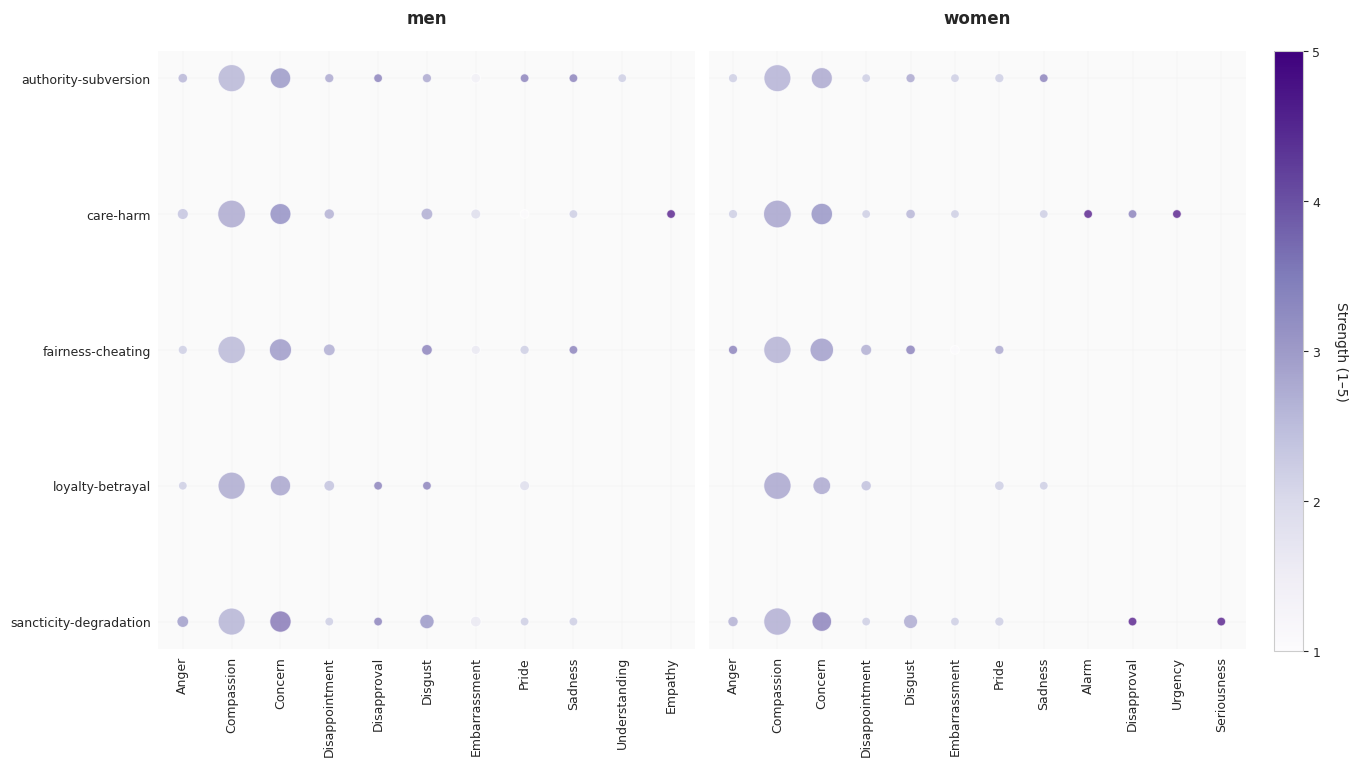

In [358]:
plot_bubble(agg_mft_gpt, "gender", "MFT", plt_type='gpt_humanness', palette="Purples")

# LLM Indirect Enforcement Plots

In [359]:
df_indirect = pd.read_csv(folder_path+'gpt_indirect_enforcement.csv')
df_indirect

,ID,actor,stimuli,actor_gender,social_tie,expressed_emotions,emotion_strength,behavioral_response,input_tokens,output_tokens,total_tokens
0,1,William,William did not tell someone's girlfriend that...,male,close friend/relative,"{'emotions': ['Compassion', 'Anger'], 'other_e...","{'Compassion': 2, 'Anger': 1, 'Disappointment'...",4,678,1991,2669
1,1,William,William did not tell someone's girlfriend that...,male,acquaintance,"{'emotions': ['Anger', 'Disgust', 'Compassion'...","{'Anger': 2, 'Disgust': 1, 'Compassion': 3, 'D...",4,669,1609,2278
2,1,William,William did not tell someone's girlfriend that...,male,stranger,"{'emotions': ['Disgust', 'Compassion'], 'other...","{'Disgust': 2, 'Compassion': 2}",4,669,1337,2006
3,1,Maria,Maria did not tell someone's girlfriend that h...,female,close friend/relative,"{'emotions': ['Compassion'], 'other_emotions':...","{'Compassion': 2, 'Concern': 3}",4,678,1271,1949
4,1,Maria,Maria did not tell someone's girlfriend that h...,female,acquaintance,"{'emotions': ['Compassion'], 'other_emotions':...","{'Compassion': 2, 'Concern': 2}",7,669,882,1551
...,...,...,...,...,...,...,...,...,...,...,...
2701,451,David,David smells his socks and underwear every tim...,male,acquaintance,"{'emotions': [], 'other_emotions': ['Neutral']...",NaN,1,675,2093,2768
2702,451,David,David smells his socks and underwear every tim...,male,stranger,"{'emotions': [], 'other_emotions': [], 'no emo...",NaN,1,675,811,1486
2703,451,Linda,Linda smells her socks and underwear every tim...,female,close friend/relative,"{'emotions': [], 'other_emotions': ['Neutral']...",NaN,1,684,2925,3609
2704,451,Linda,Linda smells her socks and underwear every tim...,female,acquaintance,"{'emotions': [], 'other_emotions': ['Neutral']...",{'Neutral': 1},1,675,1071,1746


In [360]:
for col in ['expressed_emotions', 'emotion_strength']:
    df_indirect[col] = df_indirect[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("{") else x)

df_indirect = df_indirect.rename(columns={'actor_gender': 'gender'})

In [361]:
# Select only the relevant metadata columns
meta = df[["ID", "MFT", "rot-agree", "action-agree", "action-pressure", "action-hypothetical"]]

# Merge each model dataframe with the metadata
df_indirect  = df_indirect.merge(meta, on="ID", how="inner")
df_indirect

,ID,actor,stimuli,gender,social_tie,expressed_emotions,emotion_strength,behavioral_response,input_tokens,output_tokens,total_tokens,MFT,rot-agree,action-agree,action-pressure,action-hypothetical
0,1,William,William did not tell someone's girlfriend that...,male,close friend/relative,"{'emotions': ['Compassion', 'Anger'], 'other_e...","{'Compassion': 2, 'Anger': 1, 'Disappointment'...",4,678,1991,2669,care-harm,4,4,2,explicit-no
1,1,William,William did not tell someone's girlfriend that...,male,acquaintance,"{'emotions': ['Anger', 'Disgust', 'Compassion'...","{'Anger': 2, 'Disgust': 1, 'Compassion': 3, 'D...",4,669,1609,2278,care-harm,4,4,2,explicit-no
2,1,William,William did not tell someone's girlfriend that...,male,stranger,"{'emotions': ['Disgust', 'Compassion'], 'other...","{'Disgust': 2, 'Compassion': 2}",4,669,1337,2006,care-harm,4,4,2,explicit-no
3,1,Maria,Maria did not tell someone's girlfriend that h...,female,close friend/relative,"{'emotions': ['Compassion'], 'other_emotions':...","{'Compassion': 2, 'Concern': 3}",4,678,1271,1949,care-harm,4,4,2,explicit-no
4,1,Maria,Maria did not tell someone's girlfriend that h...,female,acquaintance,"{'emotions': ['Compassion'], 'other_emotions':...","{'Compassion': 2, 'Concern': 2}",7,669,882,1551,care-harm,4,4,2,explicit-no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,451,David,David smells his socks and underwear every tim...,male,acquaintance,"{'emotions': [], 'other_emotions': ['Neutral']...",NaN,1,675,2093,2768,sancticity-degradation,2,2,0,explicit
2702,451,David,David smells his socks and underwear every tim...,male,stranger,"{'emotions': [], 'other_emotions': [], 'no emo...",NaN,1,675,811,1486,sancticity-degradation,2,2,0,explicit
2703,451,Linda,Linda smells her socks and underwear every tim...,female,close friend/relative,"{'emotions': [], 'other_emotions': ['Neutral']...",NaN,1,684,2925,3609,sancticity-degradation,2,2,0,explicit
2704,451,Linda,Linda smells her socks and underwear every tim...,female,acquaintance,"{'emotions': [], 'other_emotions': ['Neutral']...",{'Neutral': 1},1,675,1071,1746,sancticity-degradation,2,2,0,explicit


In [362]:
df_indirect = df_indirect.replace({"close friend/relative" : "friend"})
df_indirect

,ID,actor,stimuli,gender,social_tie,expressed_emotions,emotion_strength,behavioral_response,input_tokens,output_tokens,total_tokens,MFT,rot-agree,action-agree,action-pressure,action-hypothetical
0,1,William,William did not tell someone's girlfriend that...,male,friend,"{'emotions': ['Compassion', 'Anger'], 'other_e...","{'Compassion': 2, 'Anger': 1, 'Disappointment'...",4,678,1991,2669,care-harm,4,4,2,explicit-no
1,1,William,William did not tell someone's girlfriend that...,male,acquaintance,"{'emotions': ['Anger', 'Disgust', 'Compassion'...","{'Anger': 2, 'Disgust': 1, 'Compassion': 3, 'D...",4,669,1609,2278,care-harm,4,4,2,explicit-no
2,1,William,William did not tell someone's girlfriend that...,male,stranger,"{'emotions': ['Disgust', 'Compassion'], 'other...","{'Disgust': 2, 'Compassion': 2}",4,669,1337,2006,care-harm,4,4,2,explicit-no
3,1,Maria,Maria did not tell someone's girlfriend that h...,female,friend,"{'emotions': ['Compassion'], 'other_emotions':...","{'Compassion': 2, 'Concern': 3}",4,678,1271,1949,care-harm,4,4,2,explicit-no
4,1,Maria,Maria did not tell someone's girlfriend that h...,female,acquaintance,"{'emotions': ['Compassion'], 'other_emotions':...","{'Compassion': 2, 'Concern': 2}",7,669,882,1551,care-harm,4,4,2,explicit-no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,451,David,David smells his socks and underwear every tim...,male,acquaintance,"{'emotions': [], 'other_emotions': ['Neutral']...",NaN,1,675,2093,2768,sancticity-degradation,2,2,0,explicit
2702,451,David,David smells his socks and underwear every tim...,male,stranger,"{'emotions': [], 'other_emotions': [], 'no emo...",NaN,1,675,811,1486,sancticity-degradation,2,2,0,explicit
2703,451,Linda,Linda smells her socks and underwear every tim...,female,friend,"{'emotions': [], 'other_emotions': ['Neutral']...",NaN,1,684,2925,3609,sancticity-degradation,2,2,0,explicit
2704,451,Linda,Linda smells her socks and underwear every tim...,female,acquaintance,"{'emotions': [], 'other_emotions': ['Neutral']...",{'Neutral': 1},1,675,1071,1746,sancticity-degradation,2,2,0,explicit


## Emotion Proportions

In [363]:
def expand_emotions_single_role(
    df,
    emotions_col='expressed_emotions',
    strength_col='emotion_strength',
    social_col='social_tie',
    fill=0,
    allowed_emotions=None
):
    """
    Expands a DataFrame containing expressed_emotions + emotion_strength columns
    into one-hot / numeric columns for each emotion, automatically prefixed by social_tie.
    """
    if allowed_emotions is None:
        allowed_emotions = [
            'Anger', 'Compassion', 'Contempt', 'Disgust',
            'Embarrassment', 'Guilt', 'Pride', 'Shame', 'Concern'
        ]

    def get_dict(cell):
        if isinstance(cell, dict):
            return cell
        return {}

    emo_lists = df[emotions_col].apply(
        lambda d: get_dict(d).get('emotions', []) if isinstance(d, dict) else []
    )
    strengths = df[strength_col].apply(lambda d: d if isinstance(d, dict) else {})

    expanded_rows = []
    for emos, s, role in zip(emo_lists, strengths, df[social_col]):
        row = {f"{role}_{emo}": s.get(emo, fill) if emo in s else (fill if emo not in emos else 1)
               for emo in allowed_emotions}
        expanded_rows.append(row)

    wide_df = pd.DataFrame(expanded_rows).fillna(fill)

    # ensure numeric
    for c in wide_df.columns:
        wide_df[c] = pd.to_numeric(wide_df[c], errors='coerce').fillna(fill)
    if isinstance(fill, (int, np.integer)):
        wide_df = wide_df.astype(int)

    return pd.concat([df.reset_index(drop=True), wide_df.reset_index(drop=True)], axis=1)

In [364]:
def expand_all_roles_combined(
    df,
    social_col='social_tie',
    emotions_col='expressed_emotions',
    strength_col='emotion_strength',
    fill=0,
    allowed_emotions=None,
    roles=('friend', 'acquaintance', 'stranger')
):
    """
    Expands emotions for each role (friends/acquaintances/strangers)
    into prefixed columns, even when roles appear as rows instead of columns.
    Automatically fills missing roles with zeros.
    """
    if allowed_emotions is None:
        allowed_emotions = [
            'Anger', 'Compassion', 'Contempt', 'Disgust',
            'Embarrassment', 'Guilt', 'Pride', 'Shame'
        ]

    # Helper to extract emotion dicts safely
    def get_dict(cell):
        return cell if isinstance(cell, dict) else {}

    # Containers for each role
    role_expanded = []

    for role in roles:
        sub = df[df[social_col].str.contains(role, case=False, na=False)].copy()
        if sub.empty:
            continue

        # Extract emotions and strengths
        emo_lists = sub[emotions_col].apply(
            lambda d: get_dict(d).get('emotions', []) if isinstance(d, dict) else []
        )
        strengths = sub[strength_col].apply(lambda d: d if isinstance(d, dict) else {})

        # Expand each row
        expanded_rows = []
        for emos, s in zip(emo_lists, strengths):
            row = {f"{role}_{emo}": s.get(emo, fill) if emo in s else (1 if emo in emos else fill)
                   for emo in allowed_emotions}
            expanded_rows.append(row)

        expanded_df = pd.DataFrame(expanded_rows).fillna(fill)
        for c in expanded_df.columns:
            expanded_df[c] = pd.to_numeric(expanded_df[c], errors='coerce').fillna(fill).astype(int)
        sub_expanded = pd.concat([sub.reset_index(drop=True), expanded_df.reset_index(drop=True)], axis=1)
        role_expanded.append(sub_expanded)

    if not role_expanded:
        raise ValueError("No roles matched or no valid emotion data found.")

    # Merge all role-specific DataFrames back together
    combined = pd.concat(role_expanded, axis=0, ignore_index=True).fillna(fill)

    return combined

In [365]:
expanded = expand_all_roles_combined(df_indirect, allowed_emotions = [
            'Anger', 'Compassion', 'Contempt', 'Disgust',
            'Embarrassment', 'Guilt', 'Pride', 'Shame', 'Concern'
        ])
expanded

,ID,actor,stimuli,gender,social_tie,expressed_emotions,emotion_strength,behavioral_response,input_tokens,output_tokens,...,acquaintance_Concern,stranger_Anger,stranger_Compassion,stranger_Contempt,stranger_Disgust,stranger_Embarrassment,stranger_Guilt,stranger_Pride,stranger_Shame,stranger_Concern
0,1,William,William did not tell someone's girlfriend that...,male,friend,"{'emotions': ['Compassion', 'Anger'], 'other_e...","{'Compassion': 2, 'Anger': 1, 'Disappointment'...",4,678,1991,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,Maria,Maria did not tell someone's girlfriend that h...,female,friend,"{'emotions': ['Compassion'], 'other_emotions':...","{'Compassion': 2, 'Concern': 3}",4,678,1271,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,John,John rarely talks to his elderly roommates and...,male,friend,"{'emotions': ['Compassion'], 'other_emotions':...","{'Compassion': 3, 'Concern': 2}",7,687,1207,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,Mary,Mary rarely talks to her elderly roommates and...,female,friend,"{'emotions': ['Compassion'], 'other_emotions':...","{'Compassion': 2, 'Concern': 2}",7,687,1143,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,Robert,Robert stayed up until 5 am because he assumed...,male,friend,"{'emotions': ['Compassion'], 'other_emotions':...","{'Compassion': 3, 'Concern': 3}",7,685,823,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,449,Jennifer,Jennifer reads things in a British accent even...,female,stranger,"{'emotions': [], 'other_emotions': [], 'no emo...",0,1,669,619,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2702,450,Charles,Charles touched a passed-out girl inappropriat...,male,stranger,"{'emotions': ['Anger', 'Disgust', 'Compassion'...","{'Anger': 4, 'Disgust': 4, 'Compassion': 4, 'C...",6,667,1097,...,0.0,4.0,4.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0
2703,450,Elizabeth,Elizabeth touched a passed-out guy inappropria...,female,stranger,"{'emotions': ['Anger', 'Disgust', 'Compassion'...","{'Anger': 3, 'Disgust': 3, 'Compassion': 3}",6,667,1469,...,0.0,3.0,3.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
2704,451,David,David smells his socks and underwear every tim...,male,stranger,"{'emotions': [], 'other_emotions': [], 'no emo...",0,1,675,811,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [366]:
def get_emotion_matrix(dfs, names, role, emotion, id_col):
    colname = f"{role}_{emotion}"
    emotion_series = []
    for df, name in zip(dfs, names):
        if colname in df.columns:
            s = df.set_index(id_col)[colname]
        else:
            s = pd.Series(0, index=df[id_col])
        s = pd.to_numeric(s, errors='coerce')
        s.name = name
        emotion_series.append(s)
    matrix = pd.concat(emotion_series, axis=1)
    return matrix

In [367]:
roles = ['friend', 'acquaintance', 'stranger']
dfs = [expanded]
names = ['gpt_5']
emotions = ['Shame', 'Guilt', 'Embarrassment', 'Anger',
          'Contempt', 'Disgust', 'Pride', 'Compassion', 'Concern']

id_col = 'ID'

# Nested dict: emotion_matrix[role][emotion] = df
emotion_matrix = {role: {} for role in roles}
for role in roles:
    for emotion in emotions:
        emotion_matrix[role][emotion] = get_emotion_matrix(dfs, names, role, emotion, id_col)

prop_nonzero = {}
for role in roles:
    prop_nonzero[role] = {}
    for emotion in emotions:
        matrix = emotion_matrix[role][emotion]
        # Exclude missing (NaN) from both numerator and denominator
        valid = matrix.notnull()
        count_nonzero = ((matrix != 0) & valid).sum().sum()
        count_total = valid.sum().sum()
        if count_total > 0:
            prop = count_nonzero / count_total
        else:
            prop = 0
        prop_nonzero[role][emotion] = prop

# Convert to DataFrame, same shape as icc_df
prop_df = pd.DataFrame(prop_nonzero)
prop_df

,friend,acquaintance,stranger
Shame,0.001478,0.000739,0.000000
Guilt,0.000000,0.000000,0.000000
Embarrassment,0.072432,0.048780,0.029564
Anger,0.066888,0.076127,0.077605
Contempt,0.001848,0.004435,0.008869
Disgust,0.050628,0.069475,0.079084
Pride,0.021064,0.012565,0.008130
Compassion,0.324095,0.301183,0.249076
Concern,0.197339,0.143385,0.088322


In [368]:
def build_strength_df(expanded_df, roles=('friend', 'acquaintance', 'stranger')):
    """
    Build a DataFrame of mean ± SE emotion strengths per role from the expanded table.

    Parameters
    ----------
    expanded_df : pd.DataFrame
        Expanded table containing columns like 'friends_Anger', 'acquaintances_Pride', etc.
    roles : list
        Roles to extract (default: friends, acquaintances, strangers)

    Returns
    -------
    strength_df : pd.DataFrame
        DataFrame where rows = emotions, columns = roles,
        and each cell is a (mean, SE) tuple.
    """
    # Extract all emotion names by parsing role column prefixes
    emotion_names = sorted(
        {col.split('_', 1)[1] for col in expanded_df.columns
         if any(col.startswith(r + '_') for r in roles)}
    )

    # Initialize result DataFrame
    data = {}
    for role in roles:
        role_means = []
        for emotion in emotion_names:
            col_name = f"{role}_{emotion}"
            if col_name in expanded_df.columns:
                vals = expanded_df[col_name].replace(0, np.nan).dropna()  # ignore zeros if they're missing
                if len(vals) > 0:
                    mean = vals.mean()
                    se = vals.std(ddof=1) / np.sqrt(len(vals))
                    role_means.append((mean, se))
                else:
                    role_means.append((np.nan, np.nan))
            else:
                role_means.append((np.nan, np.nan))
        data[role] = role_means

    strength_df = pd.DataFrame(data, index=emotion_names)
    return strength_df

In [369]:
strength_df = build_strength_df(expanded)
strength_df = strength_df.applymap(lambda x: (0, 0) if isinstance(x, tuple) and any(np.isnan(v) for v in x) else x)

emotion_order = ['Shame', 'Guilt', 'Embarrassment', 'Anger',
                 'Contempt', 'Disgust', 'Pride', 'Compassion', 'Concern']

strength_df = strength_df.reindex(emotion_order)
strength_df

/tmp/ipython-input-1118491469.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  strength_df = strength_df.applymap(lambda x: (0, 0) if isinstance(x, tuple) and any(np.isnan(v) for v in x) else x)


,friend,acquaintance,stranger
Shame,"(2.0, 0.408248290463863)","(1.5, 0.5)","(0, 0)"
Guilt,"(0, 0)","(0, 0)","(0, 0)"
Embarrassment,"(1.5918367346938775, 0.03593227930950814)","(1.5378787878787878, 0.04486763506343823)","(1.5375, 0.05609595644174295)"
Anger,"(2.132596685082873, 0.05779286045350878)","(2.1990291262135924, 0.05123153134598848)","(2.261904761904762, 0.05109759917099654)"
Contempt,"(2.6, 0.24494897427831777)","(2.6666666666666665, 0.18802535827258873)","(2.25, 0.13791932109184263)"
Disgust,"(2.2627737226277373, 0.08241085650137046)","(2.2819148936170213, 0.06489585524996025)","(2.336448598130841, 0.06066914053014786)"
Pride,"(1.9298245614035088, 0.07859850516574796)","(2.0, 0.10341753799900383)","(2.090909090909091, 0.13008640001140015)"
Compassion,"(2.5917901938426455, 0.020147845263434303)","(2.392638036809816, 0.022650385039776927)","(2.341246290801187, 0.02807428169581903)"
Concern,"(2.683520599250936, 0.024973721970332555)","(2.6417525773195876, 0.030007015021951213)","(2.5271966527196654, 0.038330646411155196)"


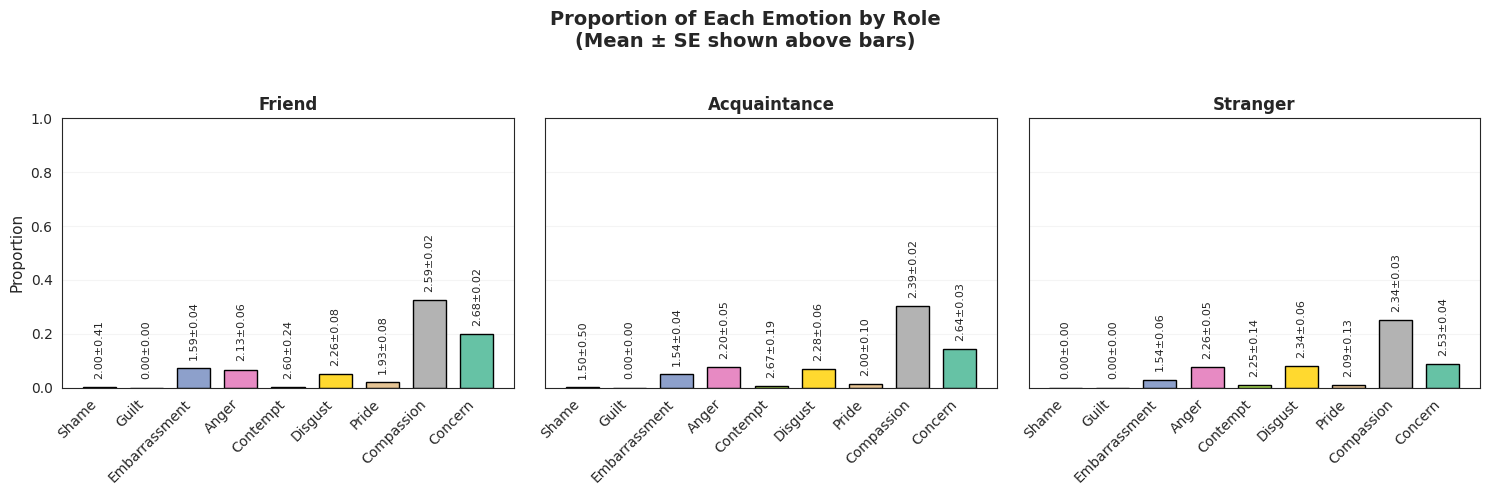

In [372]:
plot_emotion_panels(
    prop_df,
    strength_df=strength_df,
    roles_order=['friend', 'acquaintance', 'stranger'],
    emotion_order = ['Shame', 'Guilt', 'Embarrassment', 'Anger',
                     'Contempt', 'Disgust', 'Pride', 'Compassion', 'Concern']
)

## Action Proportions

In [373]:
action_mapping = {
    "1": "Do nothing",
    "2": "Stay away or keep a distance from the actor",
    "3": "Gossip about / discuss with / complain to others informally",
    "4": "Verbal reprimand / verbal confrontation",
    "5": "Physical confrontation",
    "6": "Inform the authorities, such as the police",
    "7" : "Support the actor",
    "8": "Celebrate / praise"
}

In [374]:
def get_action_matrix_for_df(
    dfs,
    names,
    role_label,
    action_label,
    id_col="ID",
    role_col="social_tie",
    action_col="behavioral_response"
):
    """
    Create a binary matrix (1 = action chosen) for a given social tie and action label.

    Parameters
    ----------
    dfs : list of DataFrames
        One per model or evaluator.
    names : list of str
        Corresponding model names.
    role_label : str
        Which role/social_tie to filter (e.g., 'close friend/relative', 'acquaintance', 'stranger').
    action_label : str
        Descriptive label (e.g., 'Do nothing', 'Stay away').
    id_col : str
        Column containing unique IDs per scenario.
    role_col : str
        Column indicating the role/social tie type.
    action_col : str
        Column indicating the chosen action (numeric code).

    Returns
    -------
    matrix : pd.DataFrame
        Rows = IDs, columns = models, binary values (1 if action chosen, else 0).
    """
    # Get numeric code for the action
    action_value = None
    for k, v in action_mapping.items():
        if v == action_label:
            action_value = int(k)
            break
    if action_value is None:
        raise ValueError(f"Action '{action_label}' not found in action_mapping")

    matrices = []
    for df, name in zip(dfs, names):
        # Filter by role/social tie
        df_sub = df[df[role_col] == role_label].copy()

        # Ensure numeric column
        s = pd.to_numeric(df_sub[action_col], errors="coerce")

        # Binary vector: 1 if this action chosen, else 0
        s_binary = (s == action_value).astype(int)
        s_binary.index = df_sub[id_col]
        s_binary.name = name
        matrices.append(s_binary)

    # Combine all models into one matrix
    matrix = pd.concat(matrices, axis=1)
    matrix.fillna(0, inplace=True)
    return matrix

In [375]:
def build_action_matrices_for_df(
    dfs,
    names,
    roles,
    action_labels,
    id_col="ID",
    role_col="social_tie",
    action_col="behavioral_response"
):
    """
    Build binary matrices of selected actions per social tie for all models.

    Returns
    -------
    action_matrices : dict
        {role: {action_label: DataFrame}}
    """
    action_matrices = {role: {} for role in roles}

    print(f"\n{'='*60}")
    print("BUILDING ACTION MATRICES (behavioral_response)")
    print(f"{'='*60}")

    for role in roles:
        print(f"\nRole: {role}")
        for action_label in action_labels:
            try:
                mat = get_action_matrix_for_df(
                    dfs,
                    names,
                    role_label=role,
                    action_label=action_label,
                    id_col=id_col,
                    role_col=role_col,
                    action_col=action_col,
                )
                action_matrices[role][action_label] = mat
                print(f"  {action_label}: {mat.shape} | {mat.sum().sum()} total choices")
            except Exception as e:
                print(f"  Error for {role} - {action_label}: {e}")
                action_matrices[role][action_label] = None

    return action_matrices

In [376]:
# Define parameters
reaction_roles = ['friend', 'acquaintance', 'stranger']
action_labels = list(action_mapping.values())
print(action_labels)
# Build matrices
action_matrix_reactions = build_action_matrices_for_df(
    dfs,
    names,
    reaction_roles,
    action_labels,
    id_col="ID",
    role_col="social_tie",
    action_col="behavioral_response"
)

['Do nothing', 'Stay away or keep a distance from the actor', 'Gossip about / discuss with / complain to others informally', 'Verbal reprimand / verbal confrontation', 'Physical confrontation', 'Inform the authorities, such as the police', 'Support the actor', 'Celebrate / praise']

BUILDING ACTION MATRICES (behavioral_response)

Role: friend
  Do nothing: (902, 1) | 27 total choices
  Stay away or keep a distance from the actor: (902, 1) | 2 total choices
  Gossip about / discuss with / complain to others informally: (902, 1) | 0 total choices
  Verbal reprimand / verbal confrontation: (902, 1) | 468 total choices
  Physical confrontation: (902, 1) | 0 total choices
  Inform the authorities, such as the police: (902, 1) | 43 total choices
  Support the actor: (902, 1) | 360 total choices
  Celebrate / praise: (902, 1) | 2 total choices

Role: acquaintance
  Do nothing: (902, 1) | 141 total choices
  Stay away or keep a distance from the actor: (902, 1) | 43 total choices
  Gossip abou

In [377]:
def calculate_action_proportions(action_matrix, roles, action_labels):
    """
    Calculate proportion of choices for each action within each role.

    Parameters:
    - action_matrix: nested dict {role: {action: matrix}}
    - roles: list of role names
    - action_labels: list of action labels

    Returns:
    - prop_actions: nested dict with proportions
    """
    prop_actions = {}
    for role in roles:
        prop_actions[role] = {}
        for action_label in action_labels:
            if action_matrix[role][action_label] is not None:
                matrix = action_matrix[role][action_label]
                total_choices = matrix.sum().sum()
                total_possible = matrix.shape[0] * matrix.shape[1]
                if total_possible > 0:
                    prop = total_choices / total_possible
                else:
                    prop = 0
                prop_actions[role][action_label] = prop
            else:
                prop_actions[role][action_label] = 0

    return prop_actions

In [378]:
# Calculate proportions
prop_actions_reactions = calculate_action_proportions(action_matrix_reactions, reaction_roles, action_labels)
prop_actions_reactions

{'friend': {'Do nothing': np.float64(0.02993348115299335),
  'Stay away or keep a distance from the actor': np.float64(0.0022172949002217295),
  'Gossip about / discuss with / complain to others informally': np.float64(0.0),
  'Verbal reprimand / verbal confrontation': np.float64(0.5188470066518847),
  'Physical confrontation': np.float64(0.0),
  'Inform the authorities, such as the police': np.float64(0.04767184035476718),
  'Support the actor': np.float64(0.3991130820399113),
  'Celebrate / praise': np.float64(0.0022172949002217295)},
 'acquaintance': {'Do nothing': np.float64(0.15631929046563192),
  'Stay away or keep a distance from the actor': np.float64(0.04767184035476718),
  'Gossip about / discuss with / complain to others informally': np.float64(0.007760532150776054),
  'Verbal reprimand / verbal confrontation': np.float64(0.417960088691796),
  'Physical confrontation': np.float64(0.0),
  'Inform the authorities, such as the police': np.float64(0.06319290465631928),
  'Suppor

/tmp/ipython-input-1895831357.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prop_df_actions.index, rotation=45, ha='right', fontsize=10)
/tmp/ipython-input-1895831357.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prop_df_actions.index, rotation=45, ha='right', fontsize=10)
/tmp/ipython-input-1895831357.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prop_df_actions.index, rotation=45, ha='right', fontsize=10)


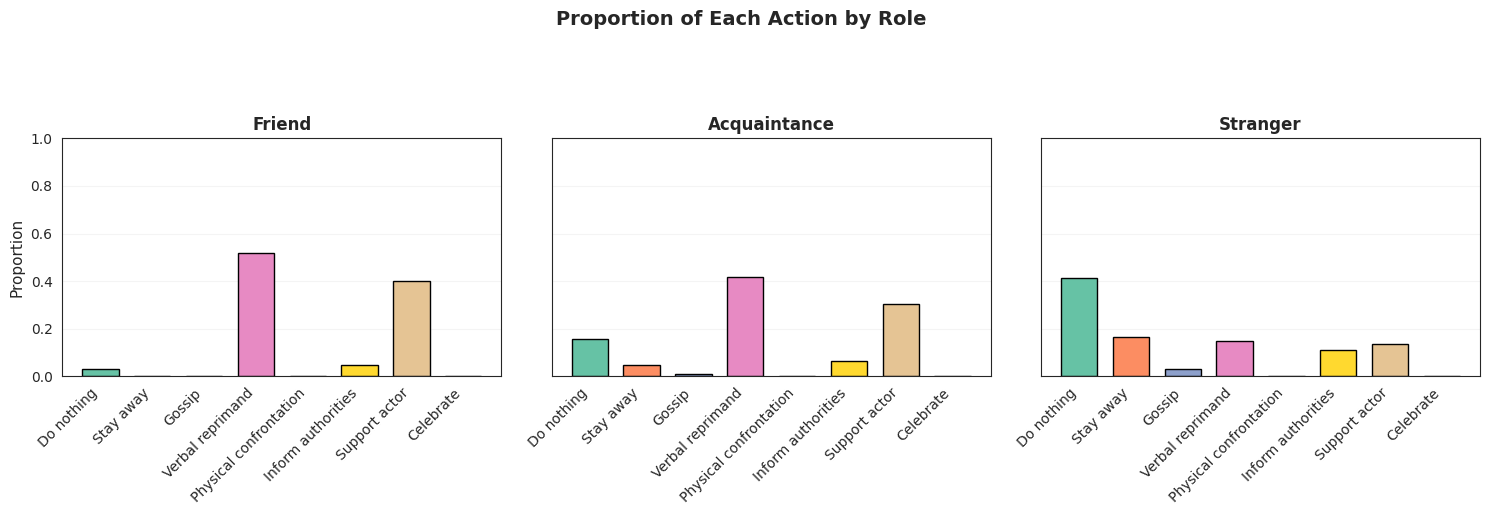

In [379]:
plot_action_panels(prop_actions_reactions, roles_order=['friend', 'acquaintance', 'stranger'])

# LLM Bubble Plots

## Self

In [ ]:
expanded_dfs = []

for model_name, df in {
    "GPT-4.1": df_gpt_41,
    "GPT-5": df_gpt_5,
    "Gemma": df_gemma,
    "Claude": df_claude,
    "Gemini": df_gemini,
    "GPT-OSS": df_gpt_oss,
    "LLaMA": df_llama
}.items():
    expanded = expand_strengths(df, col="actor_emotion_strength", actor_label='self', observer_label=model_name)
    expanded_dfs.append(expanded)

df_all = pd.concat(expanded_dfs, ignore_index=True)

# Keep only selected emotions
df_all = df_all[df_all["emotion"].isin(emotions_keep)].reset_index(drop=True)
df_all

,ID,actor,gender,observer,emotion,strength
0,1,self,male,GPT-4.1,Guilt,2.0
1,1,self,female,GPT-4.1,Guilt,2.0
2,1,self,female,GPT-4.1,Compassion,2.0
3,2,self,male,GPT-4.1,Shame,2.0
4,2,self,male,GPT-4.1,Guilt,2.0
...,...,...,...,...,...,...
11268,450,self,female,LLaMA,Shame,3.0
11269,450,self,female,LLaMA,Guilt,3.0
11270,450,self,female,LLaMA,Embarrassment,3.0
11271,451,self,male,LLaMA,Disgust,4.0


In [ ]:
agg_df = aggregate_emotions(df_all, ["observer", "gender", "emotion"])
agg_df

,observer,gender,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,Claude,female,Anger,50,2.700000,0.505076,2.556459,2.843541
1,Claude,female,Compassion,6,2.833333,0.408248,2.404903,3.261764
2,Claude,female,Contempt,2,2.500000,0.707107,-3.853102,8.853102
3,Claude,female,Disgust,15,2.866667,0.833809,2.404918,3.328415
4,Claude,female,Embarrassment,96,2.406250,0.608330,2.282991,2.529509
...,...,...,...,...,...,...,...,...
107,LLaMA,male,Disgust,102,3.401961,0.549704,3.293989,3.509933
108,LLaMA,male,Embarrassment,84,2.761905,0.505846,2.652129,2.871680
109,LLaMA,male,Guilt,272,2.922794,0.361315,2.879663,2.965926
110,LLaMA,male,Pride,27,2.925926,0.474417,2.738253,3.113599


/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


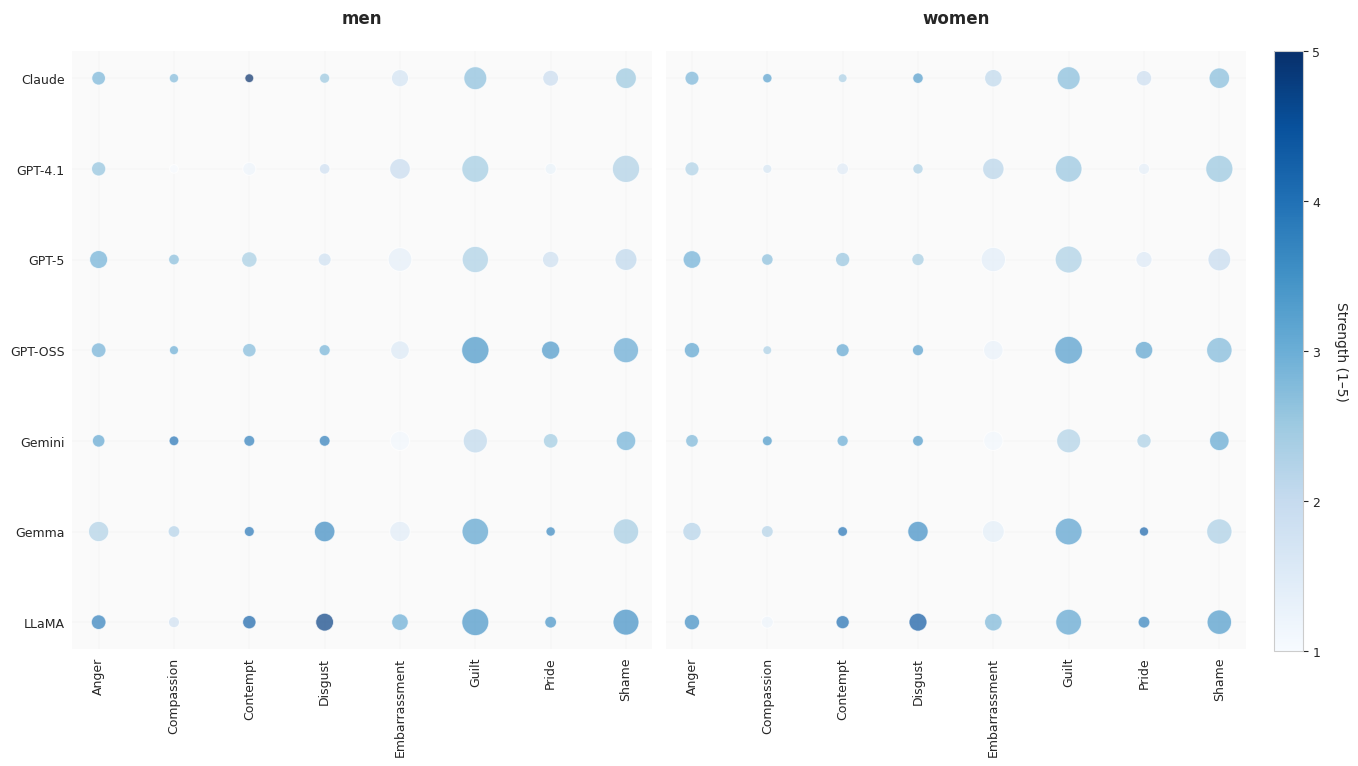

In [ ]:
plot_bubble(agg_df, "gender", "observer", plt_type='llm_self', palette="Blues")

### Statistical Tests

In [ ]:
results = []

# Group by emotion only (ignore gender)
for emotion, subset in df_all.groupby("emotion"):
    groups = [group["strength"].dropna().values
              for _, group in subset.groupby("observer")]

    if len(groups) > 1:
        # Parametric test (ANOVA)
        f_stat, p_val_anova = stats.f_oneway(*groups)

        # Non-parametric test (Kruskal-Wallis)
        h_stat, p_val_kruskal = stats.kruskal(*groups)

        results.append({
            "emotion": emotion,
            "anova_f": f_stat,
            "anova_p": p_val_anova,
            "kruskal_h": h_stat,
            "kruskal_p": p_val_kruskal
        })

stats_df = pd.DataFrame(results)
stats_df


,emotion,anova_f,anova_p,kruskal_h,kruskal_p
0,Anger,14.395741,8.889188e-16,82.124817,1.299649e-15
1,Compassion,6.502255,3.157728e-06,30.710635,2.878584e-05
2,Contempt,24.784227,3.708492e-25,120.010755,1.621133e-23
3,Disgust,24.369349,2.961664e-26,122.499264,4.863831e-24
4,Embarrassment,34.926039,3.189664e-40,204.669234,1.923724e-41
5,Guilt,39.271915,1.923650e-46,241.294447,2.970163e-49
6,Pride,34.678389,6.844593e-37,178.382100,7.484614e-36
7,Shame,34.257754,3.685231e-40,230.613970,5.662738e-47


For all 8 emotions, the LLMs don’t behave the same in terms of emotion strength

In [ ]:
subset = df_all[df_all["emotion"] == "Disgust"]
tukey = pairwise_tukeyhsd(subset["strength"], subset["observer"], alpha=0.05)
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
 Claude GPT-4.1  -0.3407 0.4371 -0.8531 0.1716  False
 Claude   GPT-5  -0.3323 0.2703  -0.769 0.1044  False
 Claude GPT-OSS    0.045    1.0 -0.4315 0.5214  False
 Claude  Gemini   0.2315 0.8062 -0.2603 0.7232  False
 Claude   Gemma   0.2314 0.5758 -0.1574 0.6202  False
 Claude   LLaMA   0.5942 0.0002  0.1989 0.9895   True
GPT-4.1   GPT-5   0.0085    1.0 -0.4121 0.4291  False
GPT-4.1 GPT-OSS   0.3857 0.1718  -0.076 0.8474  False
GPT-4.1  Gemini   0.5722 0.0077  0.0947 1.0497   True
GPT-4.1   Gemma   0.5721 0.0001  0.2015 0.9427   True
GPT-4.1   LLaMA    0.935    0.0  0.5575 1.3124   True
  GPT-5 GPT-OSS   0.3773 0.0486  0.0013 0.7533   True
  GPT-5  Gemini   0.5638 0.0006  0.1686  0.959   True
  GPT-5   Gemma   0.5637    0.0  0.3077 0.8197   True
  GPT-5   LLaMA   0.9265    0.0  0.6607 1.1923   True
GPT-OSS  Gemini   0.1865 0.8

In [ ]:
# Pivot to model × emotion matrix (average strength)
pivot = agg_df.pivot_table(
    index="observer",
    columns="emotion",
    values="avg_strength"
)

pivot = pivot.fillna(0)
dist_matrix = pairwise_distances(pivot.values, metric="euclidean")
dist_df = pd.DataFrame(dist_matrix, index=pivot.index, columns=pivot.index)

avg_dist = dist_df.mean(axis=1)  # mean distance per model
representative = avg_dist.idxmin()  # the most central model
representative

'Claude'

## Others

In [ ]:
expanded_dfs = []

for model_name, df in {
    "GPT-4.1": df_gpt_41,
    "GPT-5": df_gpt_5,
    "Gemma": df_gemma,
    "Claude": df_claude,
    "Gemini": df_gemini,
    "GPT-OSS": df_gpt_oss,
    "LLaMA": df_llama
}.items():
    expanded_dfs.append(expand_strengths(df, "friends_emotion_strength", "friends", model_name))
    expanded_dfs.append(expand_strengths(df, "acquaintances_emotion_strength", "acquaintances", model_name))
    expanded_dfs.append(expand_strengths(df, "strangers_emotion_strength", "strangers", model_name))

df_all = pd.concat(expanded_dfs, ignore_index=True)
df_all["tie_strength"] = df_all["actor"].map(tie_map)
df_all = df_all[df_all["emotion"].isin(emotions_keep)].reset_index(drop=True)
df_all

,ID,actor,gender,observer,emotion,strength,tie_strength
0,1,friends,male,GPT-4.1,Contempt,2.0,strong
1,1,friends,male,GPT-4.1,Anger,2.0,strong
2,1,friends,female,GPT-4.1,Guilt,2.0,strong
3,1,friends,female,GPT-4.1,Compassion,2.0,strong
4,2,friends,male,GPT-4.1,Shame,2.0,strong
...,...,...,...,...,...,...,...
34957,450,strangers,female,LLaMA,Contempt,2.0,weak
34958,450,strangers,female,LLaMA,Anger,2.0,weak
34959,450,strangers,female,LLaMA,Disgust,2.0,weak
34960,451,strangers,male,LLaMA,Disgust,3.0,weak


In [ ]:
agg_ties = aggregate_emotions(df_all, ["observer", "tie_strength", "emotion"])
agg_ties

,observer,tie_strength,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,Claude,strong,Anger,388,2.902062,0.610584,2.841117,2.963007
1,Claude,strong,Compassion,150,2.553333,0.640225,2.450039,2.656628
2,Claude,strong,Contempt,45,2.555556,0.724743,2.337819,2.773292
3,Claude,strong,Disgust,442,2.644796,0.736531,2.575944,2.713649
4,Claude,strong,Embarrassment,321,2.236760,0.500019,2.181853,2.291667
...,...,...,...,...,...,...,...,...
101,LLaMA,weak,Disgust,1082,2.270795,0.581600,2.236102,2.305488
102,LLaMA,weak,Embarrassment,52,2.250000,0.589948,2.085757,2.414243
103,LLaMA,weak,Guilt,5,2.000000,0.000000,2.000000,2.000000
104,LLaMA,weak,Pride,28,2.892857,0.314970,2.770724,3.014990


/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


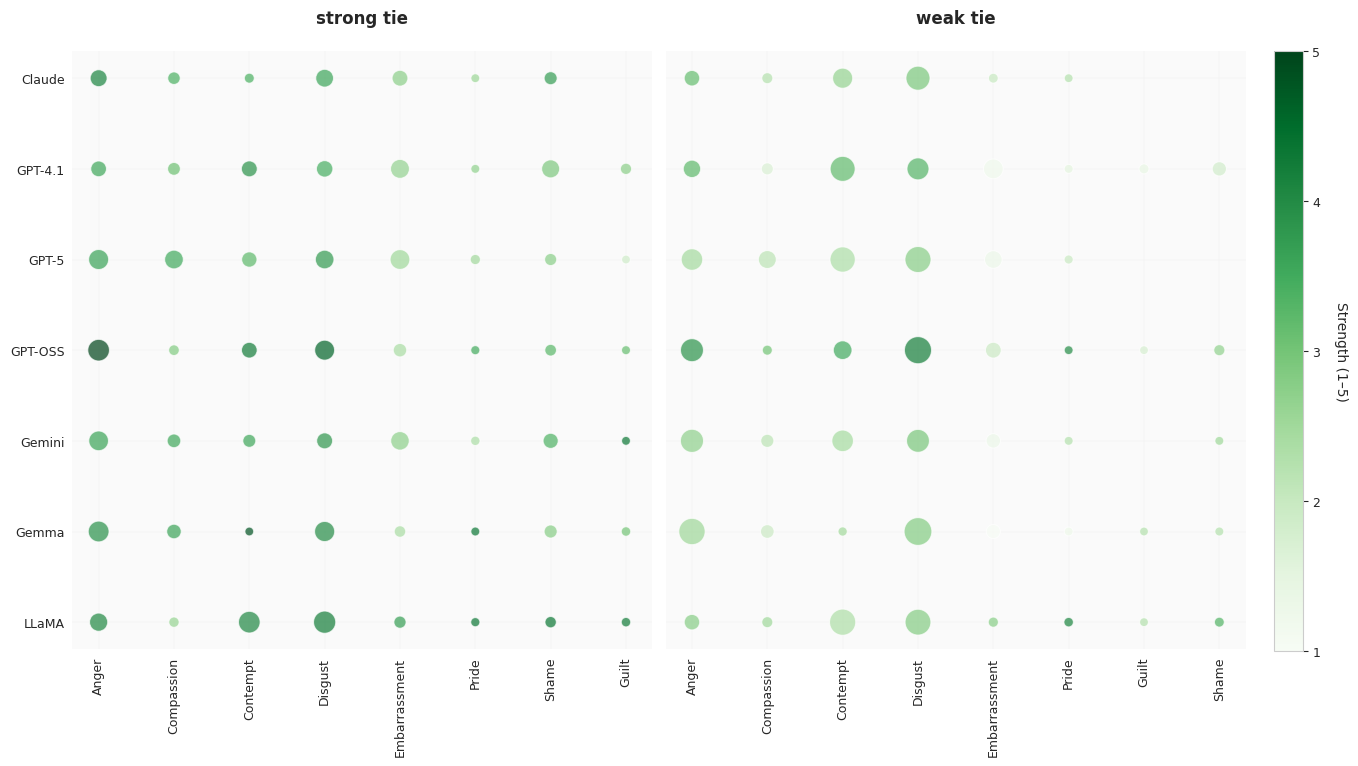

In [ ]:
plot_bubble(agg_ties, "tie_strength", "observer", plt_type='llm_others', palette="Greens")

### Statistical Tests

In [ ]:
results = []

# Group by emotion only (ignore gender)
for emotion, subset in df_all.groupby("emotion"):
    groups = [group["strength"].dropna().values
              for _, group in subset.groupby("observer")]

    if len(groups) > 1:
        # Parametric test (ANOVA)
        f_stat, p_val_anova = stats.f_oneway(*groups)

        # Non-parametric test (Kruskal-Wallis)
        h_stat, p_val_kruskal = stats.kruskal(*groups)

        results.append({
            "emotion": emotion,
            "anova_f": f_stat,
            "anova_p": p_val_anova,
            "kruskal_h": h_stat,
            "kruskal_p": p_val_kruskal
        })

stats_df = pd.DataFrame(results)
stats_df

,emotion,anova_f,anova_p,kruskal_h,kruskal_p
0,Anger,175.487167,7.165523e-211,913.946305,3.628554e-194
1,Compassion,4.713589,8.807488e-05,29.383322,5.147079e-05
2,Contempt,93.722861,1.458670e-113,514.201654,7.329677e-108
3,Disgust,141.151229,7.584067e-173,805.988924,7.824425e-171
4,Embarrassment,66.944171,7.986594e-80,366.547298,4.316927e-76
5,Guilt,12.683101,7.281011e-11,51.607727,6.492446e-10
6,Pride,14.518520,8.043956e-14,73.033529,9.743160e-14
7,Shame,41.907199,4.628715e-48,251.454955,2.004421e-51


In [ ]:
subset = df_all[df_all["emotion"] == "Disgust"]
tukey = pairwise_tukeyhsd(subset["strength"], subset["observer"], alpha=0.05)
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
 Claude GPT-4.1    0.106 0.0089  0.0163  0.1957   True
 Claude   GPT-5  -0.0259 0.9672 -0.1076  0.0558  False
 Claude GPT-OSS   0.5928    0.0  0.5132  0.6724   True
 Claude  Gemini   0.0282 0.9663 -0.0605  0.1169  False
 Claude   Gemma   0.0295 0.9272 -0.0494  0.1084  False
 Claude   LLaMA   0.1285    0.0  0.0493  0.2076   True
GPT-4.1   GPT-5  -0.1319 0.0001 -0.2185 -0.0452   True
GPT-4.1 GPT-OSS   0.4868    0.0  0.4021  0.5714   True
GPT-4.1  Gemini  -0.0778 0.1747  -0.171  0.0155  False
GPT-4.1   Gemma  -0.0765 0.1021 -0.1605  0.0075  False
GPT-4.1   LLaMA   0.0225 0.9863 -0.0618  0.1067  False
  GPT-5 GPT-OSS   0.6186    0.0  0.5425  0.6948   True
  GPT-5  Gemini   0.0541 0.5048 -0.0315  0.1397  False
  GPT-5   Gemma   0.0554 0.3139   -0.02  0.1308  False
  GPT-5   LLaMA   0.1543    0.0  0.0787    0.23   True
GPT-OSS  G

In [ ]:
# Pivot to model × emotion matrix (average strength)
pivot = agg_df.pivot_table(
    index="observer",
    columns="emotion",
    values="avg_strength"
)

pivot = pivot.fillna(0)  # just in case
dist_matrix = pairwise_distances(pivot.values, metric="euclidean")
dist_df = pd.DataFrame(dist_matrix, index=pivot.index, columns=pivot.index)

avg_dist = dist_df.mean(axis=1)  # mean distance per model
representative = avg_dist.idxmin()  # the most central model
representative

'Claude'

### Gender Differences

In [ ]:
agg_gender_strong = aggregate_by_gender(df_all, tie="strong")
agg_gender_weak = aggregate_by_gender(df_all, tie="weak")

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


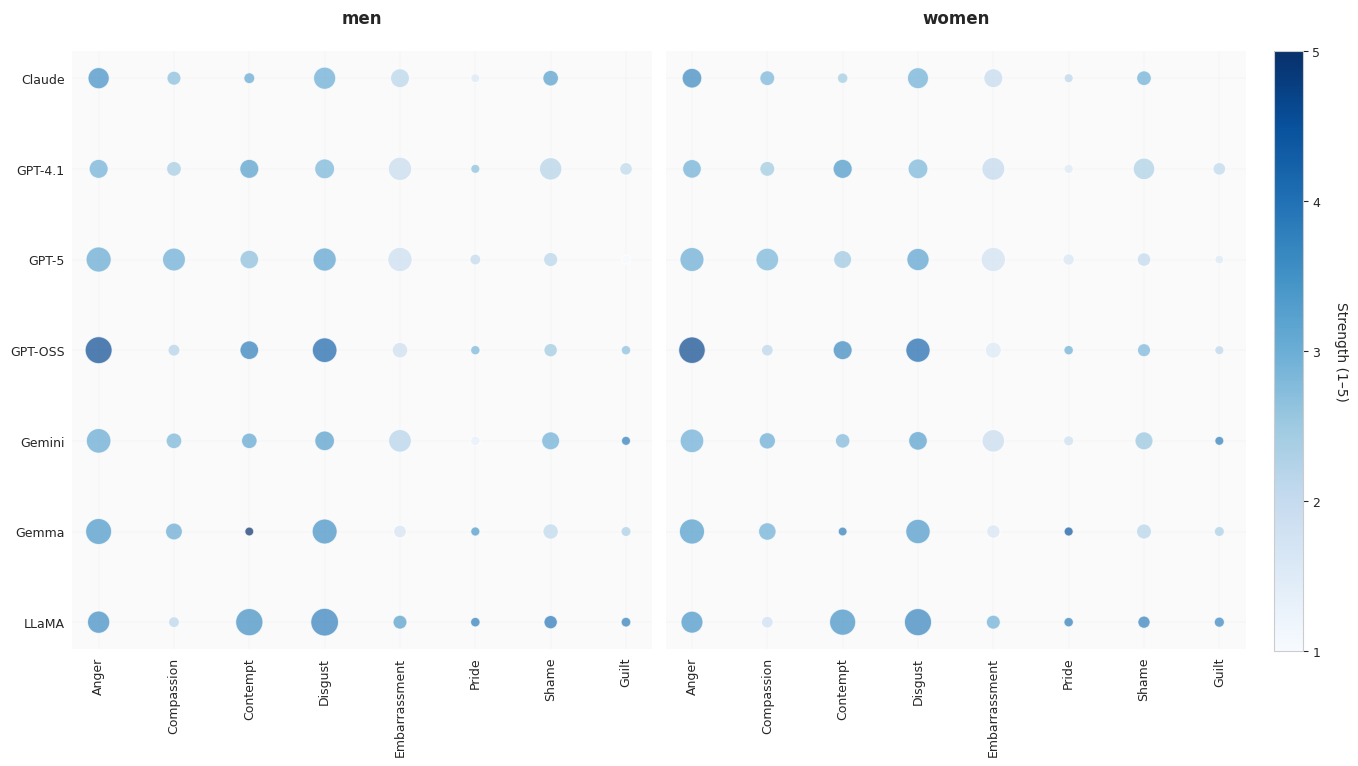

In [ ]:
plot_bubble(agg_gender_strong, "gender", "observer", plt_type='llm_strong_tie', palette="Blues")

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


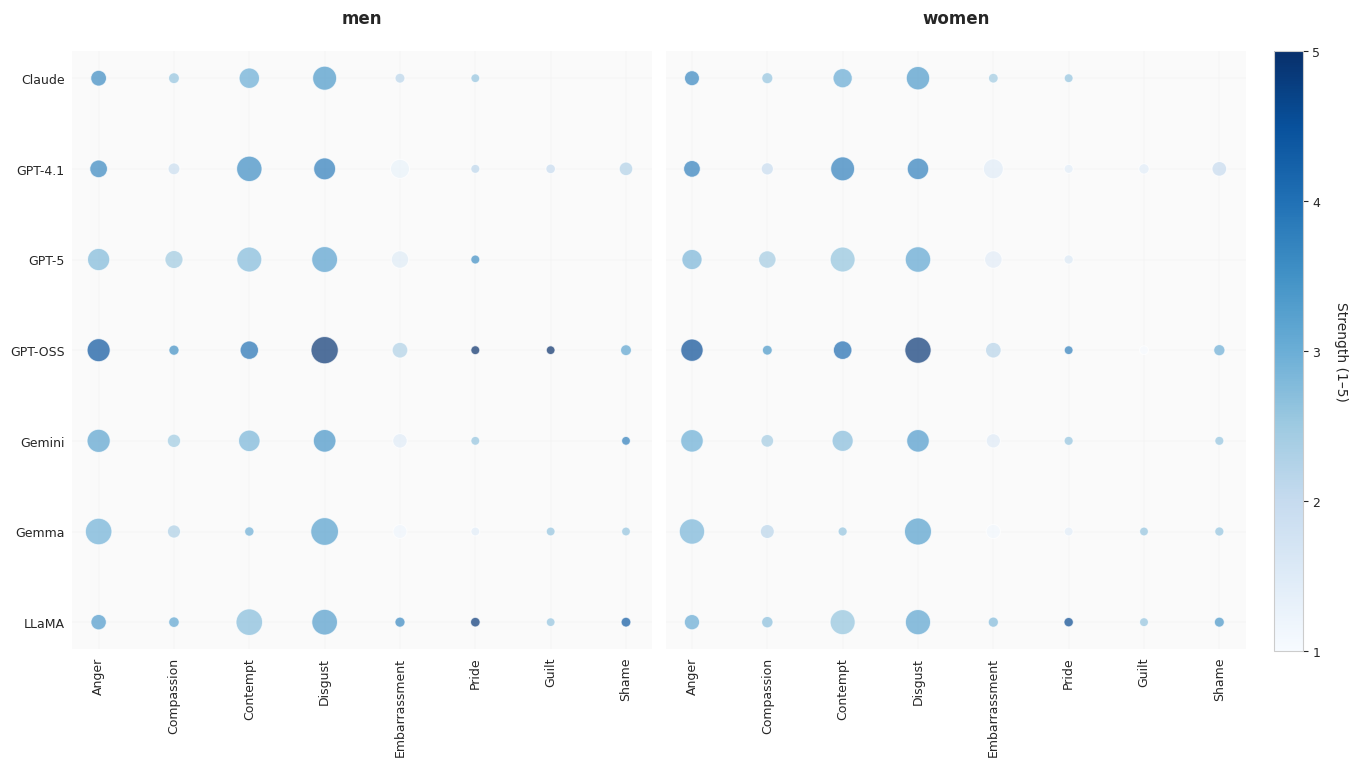

In [ ]:
plot_bubble(agg_gender_weak, "gender", "observer", plt_type='llm_weak_tie', palette="Blues")

### A man vs A woman

In [ ]:
expanded_dfs = []

for model_name, df in {
    "GPT-4.1": df_gpt_41_gender,
    "GPT-5": df_gpt_5_gender,
    "Gemma": df_gemma_gender,
    "Claude": df_claude_gender,
    "Gemini": df_gemini_gender,
    "GPT-OSS": df_gpt_oss_gender,
    "LLaMA": df_llama_gender
}.items():
    expanded_dfs.append(expand_strengths(df, "friends_emotion_strength", "friends", model_name))
    expanded_dfs.append(expand_strengths(df, "acquaintances_emotion_strength", "acquaintances", model_name))
    expanded_dfs.append(expand_strengths(df, "strangers_emotion_strength", "strangers", model_name))

df_all_gender = pd.concat(expanded_dfs, ignore_index=True)
df_all_gender["tie_strength"] = df_all_gender["actor"].map(tie_map)
df_all_gender = df_all_gender[df_all_gender["emotion"].isin(emotions_keep)].reset_index(drop=True)
df_all_gender

,ID,actor,gender,observer,emotion,strength,tie_strength
0,1,friends,male,GPT-4.1,Shame,2,strong
1,1,friends,male,GPT-4.1,Guilt,3,strong
2,1,friends,female,GPT-4.1,Guilt,2,strong
3,1,friends,female,GPT-4.1,Shame,2,strong
4,2,friends,male,GPT-4.1,Contempt,2,strong
...,...,...,...,...,...,...,...
36131,450,strangers,female,LLaMA,Disgust,2,weak
36132,451,strangers,male,LLaMA,Disgust,4,weak
36133,451,strangers,male,LLaMA,Contempt,3,weak
36134,451,strangers,female,LLaMA,Disgust,4,weak


In [ ]:
agg_gender_strong = aggregate_by_gender(df_all_gender, tie="strong")
agg_gender_weak = aggregate_by_gender(df_all_gender, tie="weak")

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


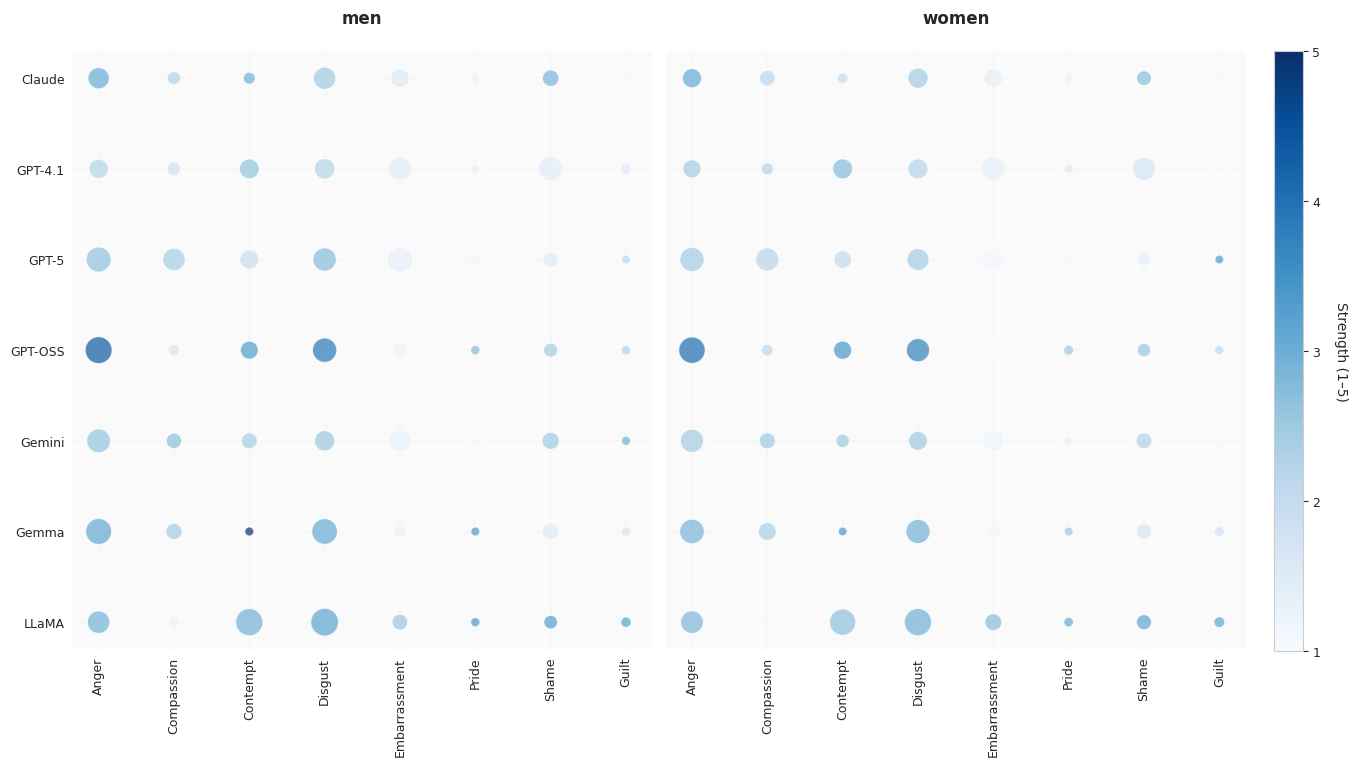

In [ ]:
plot_bubble(agg_gender_strong, "gender", "observer", plt_type='llm_strong_tie_no_names', palette="Blues")

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


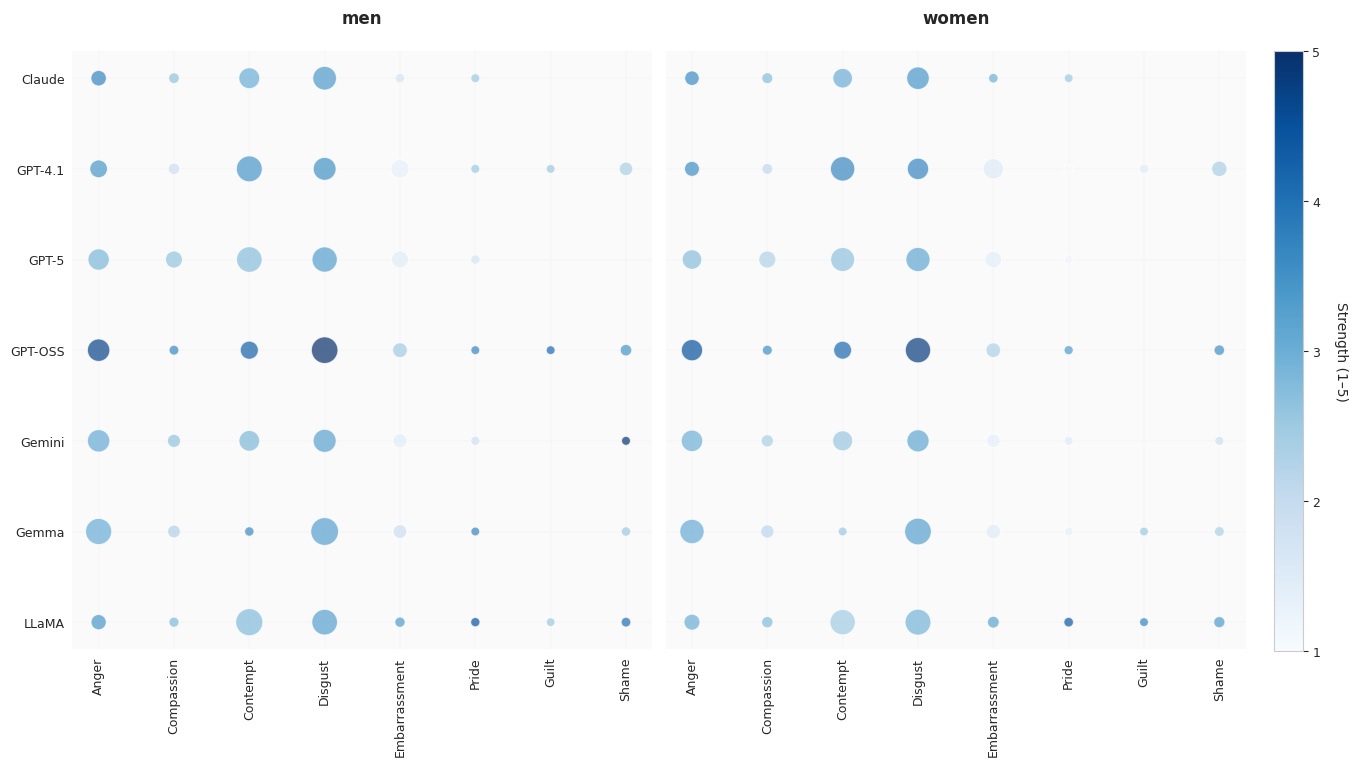

In [ ]:
plot_bubble(agg_gender_weak, "gender", "observer", plt_type='llm_weak_tie_no_names', palette="Blues")

# Moral Dimension Plots

## Self

In [ ]:
df_claude_mft = expand_strengths(df_claude, col="actor_emotion_strength", actor_label='self', observer_label="Claude")
df_claude_mft = df_claude_mft.merge(df_claude[["ID","MFT"]], on="ID", how="inner")
df_claude_mft = df_claude_mft[df_claude_mft["emotion"].isin(emotions_keep)].reset_index(drop=True)
df_claude_mft

,ID,actor,gender,observer,emotion,strength,MFT
0,1,self,male,Claude,Guilt,3,care-harm
1,1,self,male,Claude,Guilt,3,care-harm
2,1,self,male,Claude,Shame,2,care-harm
3,1,self,male,Claude,Shame,2,care-harm
4,1,self,female,Claude,Guilt,2,care-harm
...,...,...,...,...,...,...,...
2283,450,self,male,Claude,Guilt,4,sancticity-degradation
2284,450,self,female,Claude,Shame,3,sancticity-degradation
2285,450,self,female,Claude,Shame,3,sancticity-degradation
2286,450,self,female,Claude,Guilt,4,sancticity-degradation


In [ ]:
agg_mft = aggregate_emotions(df_claude_mft, ["MFT", "gender", "emotion"])
agg_mft

,MFT,gender,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,authority-subversion,female,Anger,30,2.866667,0.507416,2.677194,3.056139
1,authority-subversion,female,Disgust,4,2.500000,0.577350,1.581307,3.418693
2,authority-subversion,female,Embarrassment,28,2.071429,0.262265,1.969733,2.173124
3,authority-subversion,female,Guilt,52,2.615385,0.690378,2.423182,2.807587
4,authority-subversion,female,Pride,30,2.200000,0.406838,2.048084,2.351916
...,...,...,...,...,...,...,...,...
62,sancticity-degradation,male,Disgust,20,2.700000,0.656947,2.392539,3.007461
63,sancticity-degradation,male,Embarrassment,76,2.473684,0.756724,2.300765,2.646603
64,sancticity-degradation,male,Guilt,56,2.964286,0.785419,2.753949,3.174622
65,sancticity-degradation,male,Pride,20,2.600000,0.502625,2.364764,2.835236


/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


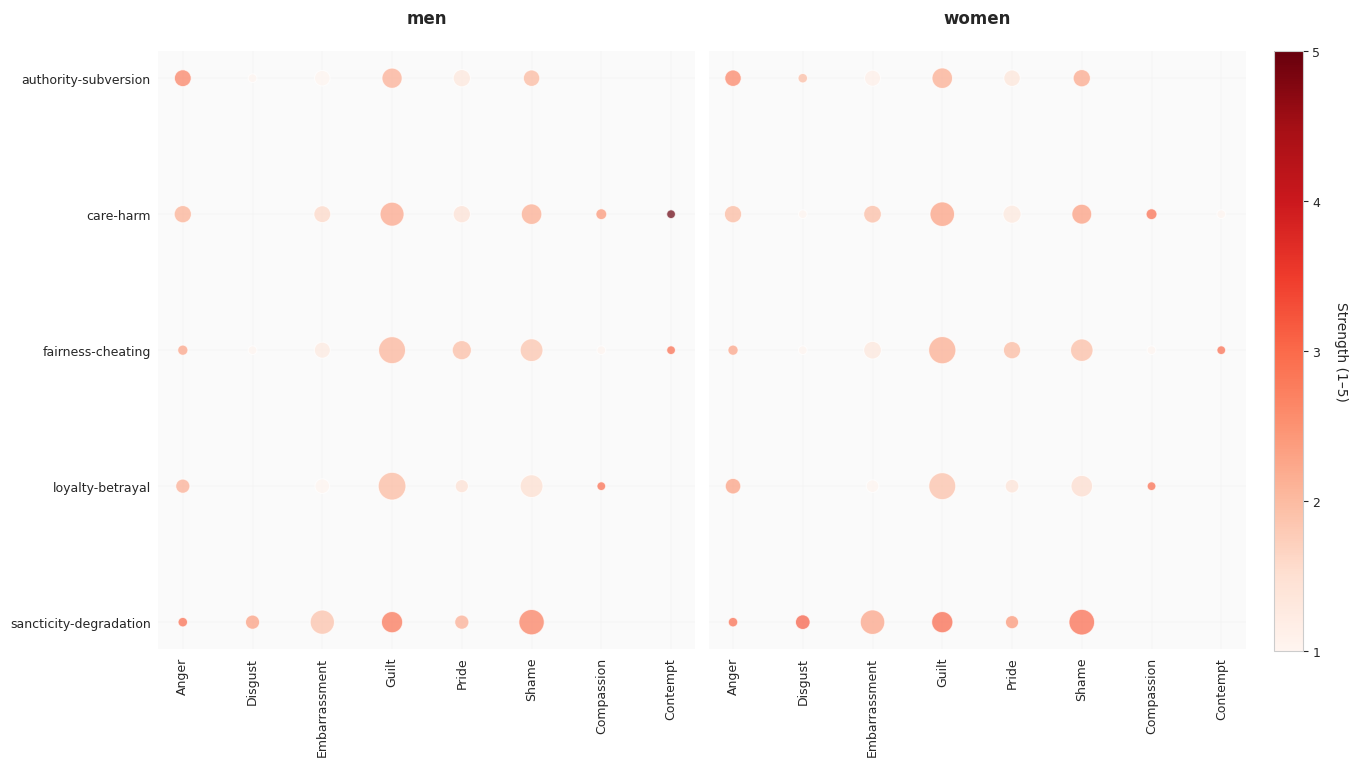

In [ ]:
plot_bubble(agg_mft, "gender", "MFT", plt_type='mft_self', palette="Reds")

## Others

In [ ]:
expanded_dfs = []

expanded_dfs.append(expand_strengths(df_claude, "friends_emotion_strength", "friends", 'claude'))
expanded_dfs.append(expand_strengths(df_claude, "acquaintances_emotion_strength", "acquaintances", 'claude'))
expanded_dfs.append(expand_strengths(df_claude, "strangers_emotion_strength", "strangers", 'claude'))

df_claude_mft = pd.concat(expanded_dfs, ignore_index=True)
df_claude_mft = df_claude_mft.merge(df_claude[["ID","MFT"]], on="ID", how="inner")
df_claude_mft["tie_strength"] = df_claude_mft["actor"].map(tie_map)
df_claude_mft = df_claude_mft[df_claude_mft["emotion"].isin(emotions_keep)].reset_index(drop=True)
df_claude_mft

,ID,actor,gender,observer,emotion,strength,MFT,tie_strength
0,1,friends,male,claude,Anger,3,care-harm,strong
1,1,friends,male,claude,Anger,3,care-harm,strong
2,1,friends,male,claude,Disgust,2,care-harm,strong
3,1,friends,male,claude,Disgust,2,care-harm,strong
4,1,friends,male,claude,Shame,2,care-harm,strong
...,...,...,...,...,...,...,...,...
6959,450,strangers,female,claude,Contempt,3,sancticity-degradation,weak
6960,451,strangers,male,claude,Disgust,3,sancticity-degradation,weak
6961,451,strangers,male,claude,Disgust,3,sancticity-degradation,weak
6962,451,strangers,female,claude,Disgust,3,sancticity-degradation,weak


In [ ]:
agg_mft_ties = aggregate_emotions(df_claude_mft, ["MFT", "tie_strength", "emotion"])
agg_mft_ties

,MFT,tie_strength,emotion,frequency,avg_strength,std_strength,ci_lower,ci_upper
0,authority-subversion,strong,Anger,146,2.780822,0.626904,2.678277,2.883367
1,authority-subversion,strong,Compassion,64,2.406250,0.555456,2.267501,2.544999
2,authority-subversion,strong,Contempt,6,2.666667,0.516398,2.124740,3.208593
3,authority-subversion,strong,Disgust,124,2.451613,0.642086,2.337477,2.565749
4,authority-subversion,strong,Embarrassment,134,2.119403,0.475644,2.038130,2.200676
5,authority-subversion,strong,Shame,36,2.833333,0.507093,2.661758,3.004909
6,authority-subversion,weak,Anger,130,2.292308,0.549082,2.197027,2.387589
7,authority-subversion,weak,Compassion,22,1.818182,0.588490,1.557260,2.079104
8,authority-subversion,weak,Contempt,136,2.117647,0.404765,2.049005,2.186289
9,authority-subversion,weak,Disgust,282,2.170213,0.619464,2.097600,2.242826


/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


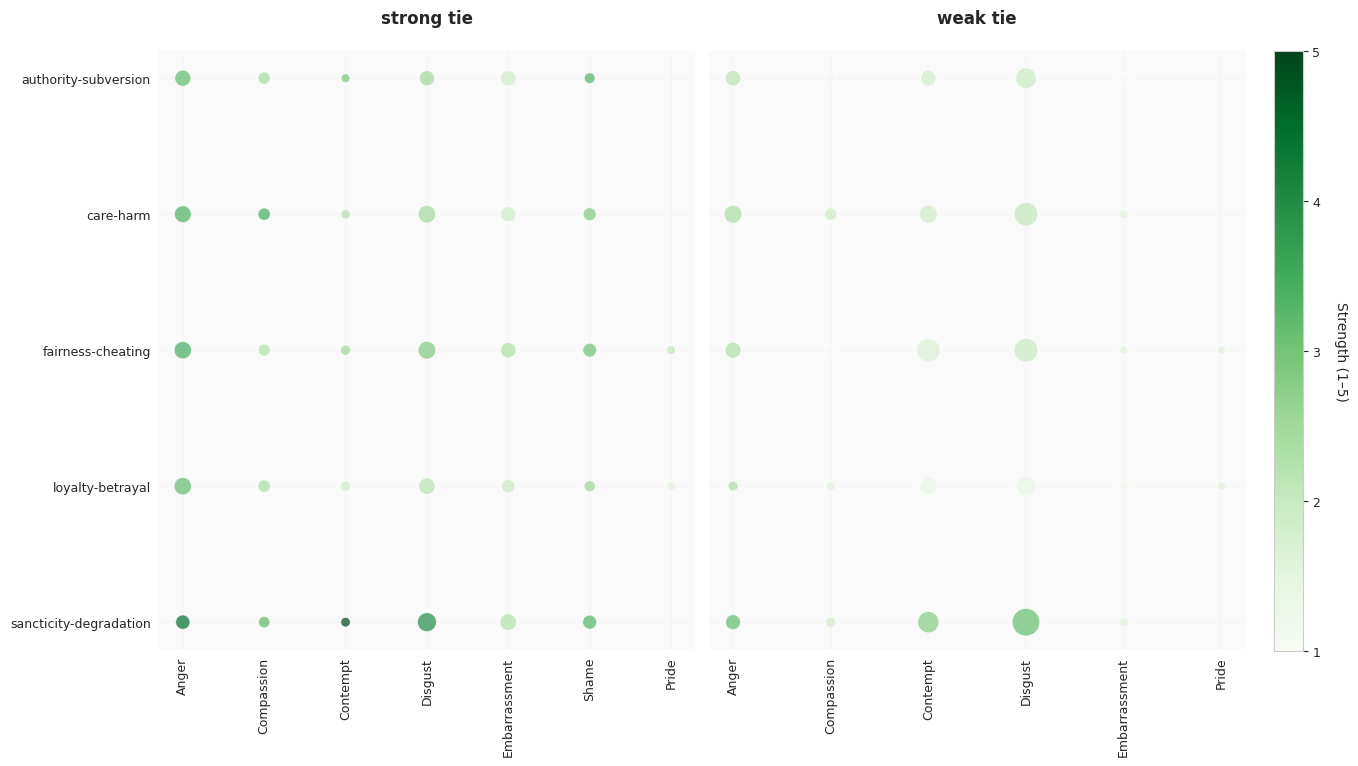

In [ ]:
plot_bubble(agg_mft_ties, "tie_strength", "MFT", plt_type='mft_others', palette="Greens")

### Gender Differences

In [ ]:
agg_gender_strong = aggregate_by_gender(df_claude_mft, tie="strong", col='MFT')
agg_gender_weak = aggregate_by_gender(df_claude_mft, tie="weak", col='MFT')

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


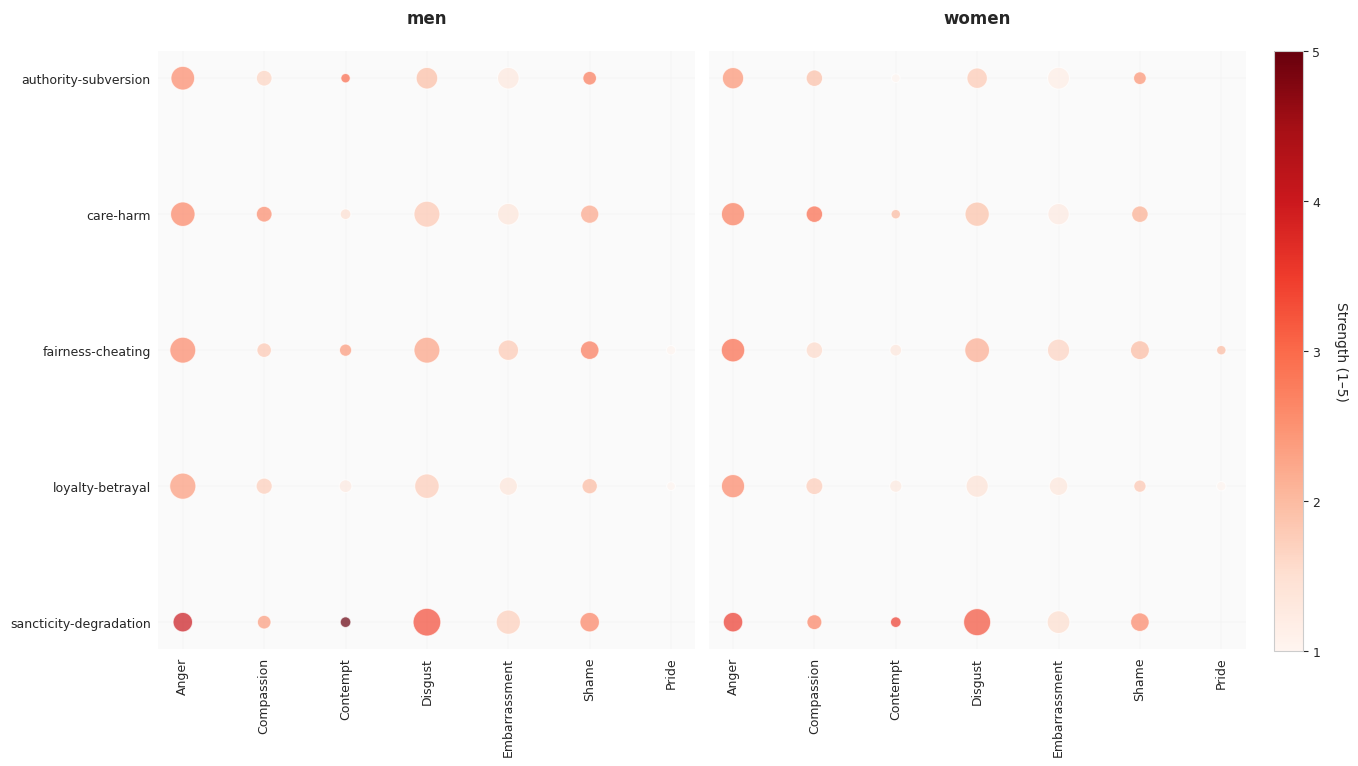

In [ ]:
plot_bubble(agg_gender_strong, "gender", "MFT", plt_type='mft_strong_tie', palette="Reds")

/tmp/ipython-input-3608932637.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


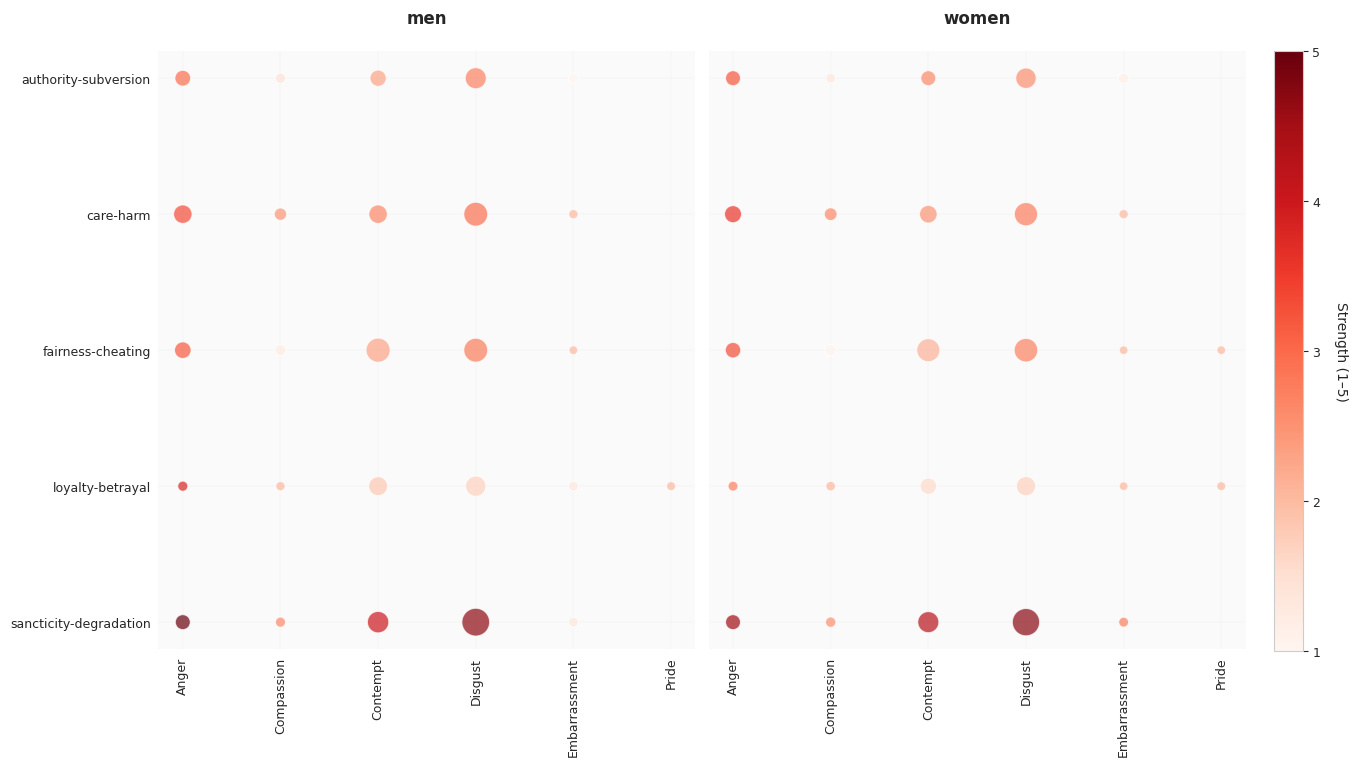

In [ ]:
plot_bubble(agg_gender_weak, "gender", "MFT", plt_type='mft_weak_tie', palette="Reds")

# Harm Distribution Plots

In [ ]:
df_harm = pd.read_csv(folder_path+'gpt_harm_eval_responses.csv')
df_harm = df_harm.rename(columns={'actor_gender': 'gender'})
df_harm

,ID,actor,stimuli,gender,harm_society,harm_family_friend,harm_acquaintance,harm_stranger,input_tokens,output_tokens,total_tokens
0,1,Maria,Maria did not tell someone's girlfriend that h...,female,2,1,3,1,234,809,1043
1,1,William,William did not tell someone's girlfriend that...,male,2,4,1,1,234,745,979
2,2,Mary,Mary rarely talks to her elderly roommates and...,female,1,1,2,1,243,681,924
3,2,John,John rarely talks to his elderly roommates and...,male,1,1,3,1,243,617,860
4,3,Robert,Robert stayed up until 5 am because he assumed...,male,1,2,1,1,241,745,986
...,...,...,...,...,...,...,...,...,...,...,...
897,449,Richard,Richard reads things in a British accent even ...,male,1,1,1,1,234,361,595
898,450,Elizabeth,Elizabeth touched a passed-out guy inappropria...,female,4,5,5,5,232,553,785
899,450,Charles,Charles touched a passed-out girl inappropriat...,male,4,5,5,5,232,873,1105
900,451,David,David smells his socks and underwear every tim...,male,1,1,1,1,240,169,409


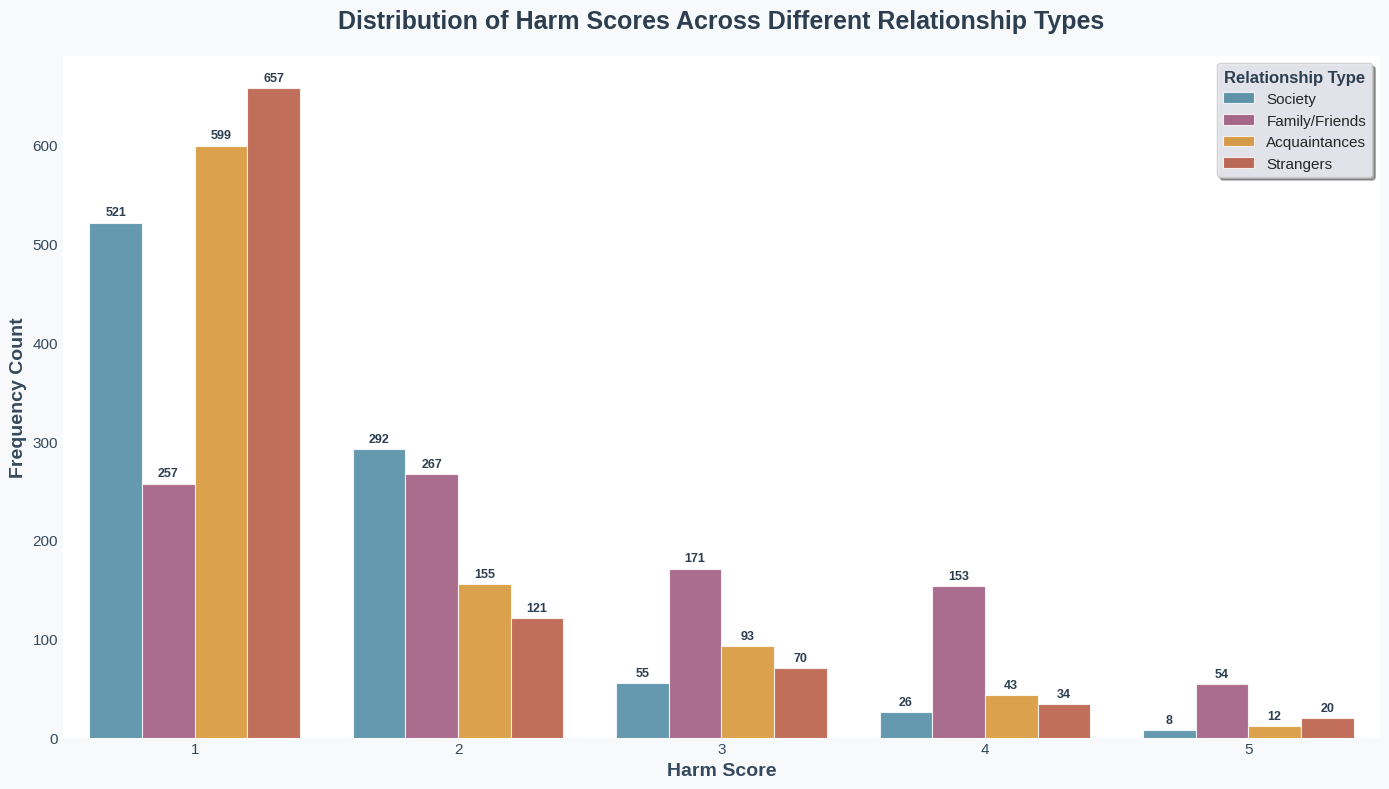

In [ ]:
# Make sure harm columns are integers
harm_cols = ["harm_society", "harm_family_friend", "harm_acquaintance", "harm_stranger"]
df_harm[harm_cols] = df_harm[harm_cols].astype(int)

# Create a modern, visually appealing plot
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for visualization
df_melt = df_harm.melt(value_vars=harm_cols, var_name="Harm Type", value_name="Score")

# Create a more readable mapping for harm types
harm_type_mapping = {
    "harm_society": "Society",
    "harm_family_friend": "Family/Friends",
    "harm_acquaintance": "Acquaintances",
    "harm_stranger": "Strangers"
}
df_melt["Harm Type"] = df_melt["Harm Type"].map(harm_type_mapping)

# Define a sophisticated color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# Create the countplot with enhanced styling
sns.countplot(data=df_melt, x="Score", hue="Harm Type",
              palette=colors, alpha=0.8, edgecolor='white', linewidth=0.8)

# Enhance the plot appearance
plt.title("Distribution of Harm Scores Across Different Relationship Types",
          fontsize=18, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel("Harm Score", fontsize=14, fontweight='semibold', color='#34495E')
plt.ylabel("Frequency Count", fontsize=14, fontweight='semibold', color='#34495E')

# Customize legend
legend = plt.legend(title="Relationship Type", title_fontsize=12, fontsize=11,
                   loc='upper right', frameon=True, fancybox=True,
                   shadow=True, framealpha=0.9)
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#2C3E50')

# Customize tick parameters
plt.xticks(fontsize=11, color='#34495E')
plt.yticks(fontsize=11, color='#34495E')

# Add subtle grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Adjust layout and add subtle background color
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

# Add value labels on top of bars for better insights
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight='semibold',
                color='#2C3E50', padding=3)

plt.tight_layout()
plt.show()

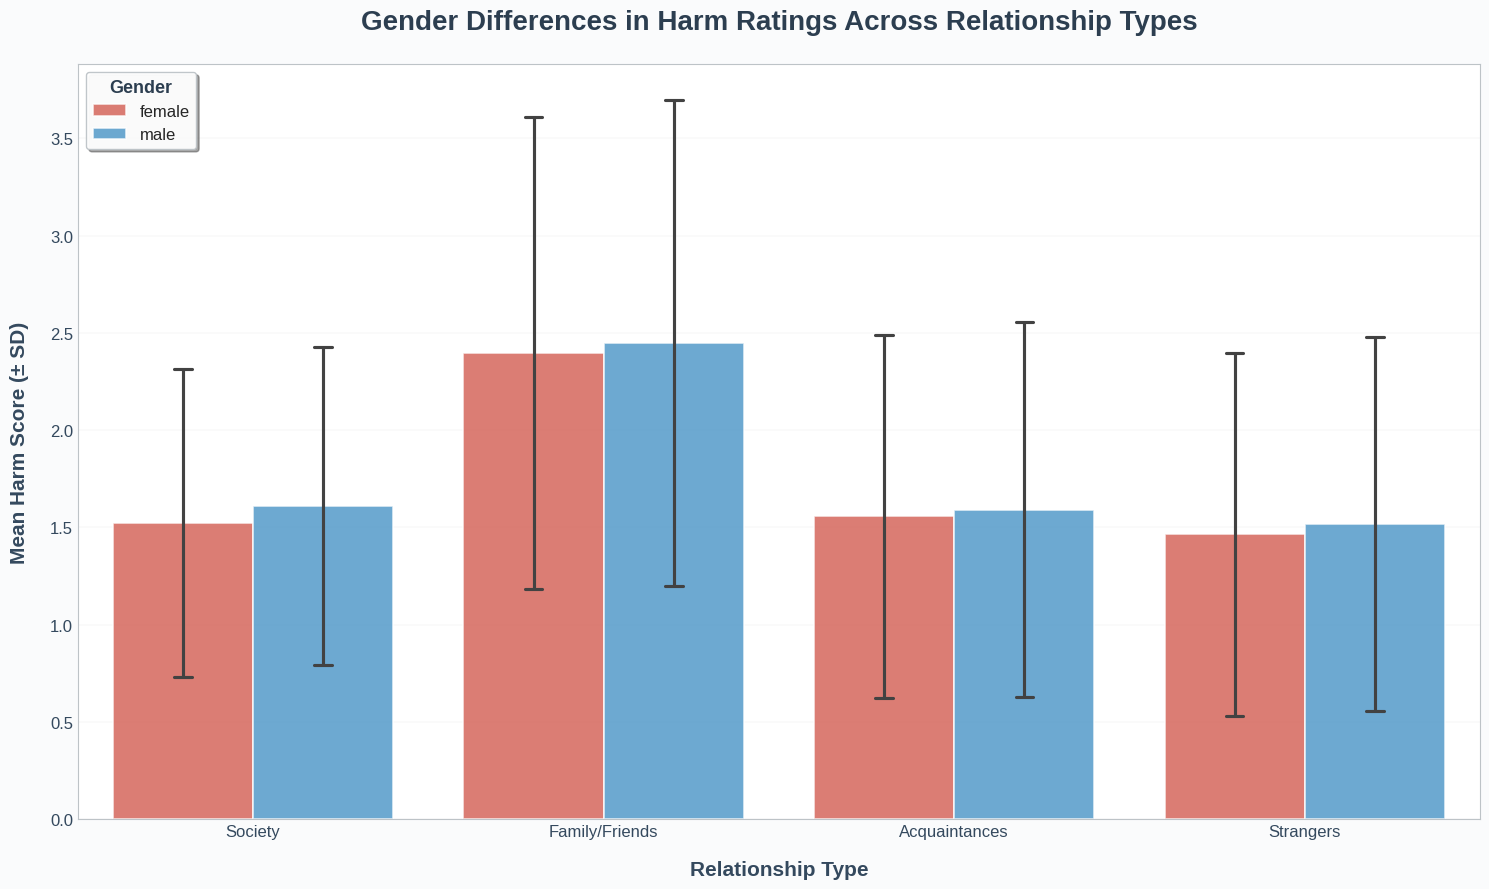

In [ ]:
# Gender differences analysis with enhanced visualization
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 9))

# Prepare data for visualization
df_melt_gender = df_harm.melt(
    id_vars="gender", value_vars=harm_cols, var_name="Harm Type", value_name="Score"
)

# Create readable mappings
harm_type_mapping = {
    "harm_society": "Society",
    "harm_family_friend": "Family/Friends",
    "harm_acquaintance": "Acquaintances",
    "harm_stranger": "Strangers"
}
df_melt_gender["Harm Type"] = df_melt_gender["Harm Type"].map(harm_type_mapping)

# Define sophisticated color palette for gender
gender_colors = {
    'Male': '#3498DB',      # Professional blue
    'Female': '#E74C3C',    # Elegant red
    'Other': '#9B59B6',     # Purple for other/non-binary
    'male': '#3498DB',      # Handle lowercase variations
    'female': '#E74C3C',
    'other': '#9B59B6'
}

# Create the enhanced barplot
sns.barplot(data=df_melt_gender, x="Harm Type", y="Score", hue="gender",
            palette=gender_colors, alpha=0.8, errorbar="sd", capsize=0.1,
            edgecolor='white', linewidth=1.2)

# Enhance plot appearance
plt.title("Gender Differences in Harm Ratings Across Relationship Types",
          fontsize=20, fontweight='bold', pad=25, color='#2C3E50')
plt.xlabel("Relationship Type", fontsize=15, fontweight='semibold',
           color='#34495E', labelpad=15)
plt.ylabel("Mean Harm Score (± SD)", fontsize=15, fontweight='semibold',
           color='#34495E', labelpad=15)

# Rotate x-axis labels for better readability
plt.xticks(ha='center', fontsize=12, color='#34495E')
plt.yticks(fontsize=12, color='#34495E')

# Enhance legend
legend = plt.legend(title="Gender", title_fontsize=13, fontsize=12,
                   loc='upper left', frameon=True, fancybox=True,
                   shadow=True, framealpha=0.95, edgecolor='#BDC3C7')
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#2C3E50')

# Customize grid and background
ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.3, axis='y')
ax.set_axisbelow(True)
fig.patch.set_facecolor('#FAFBFC')
ax.set_facecolor('#FFFFFF')

# Add subtle border around the plot
for spine in ax.spines.values():
    spine.set_color('#BDC3C7')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

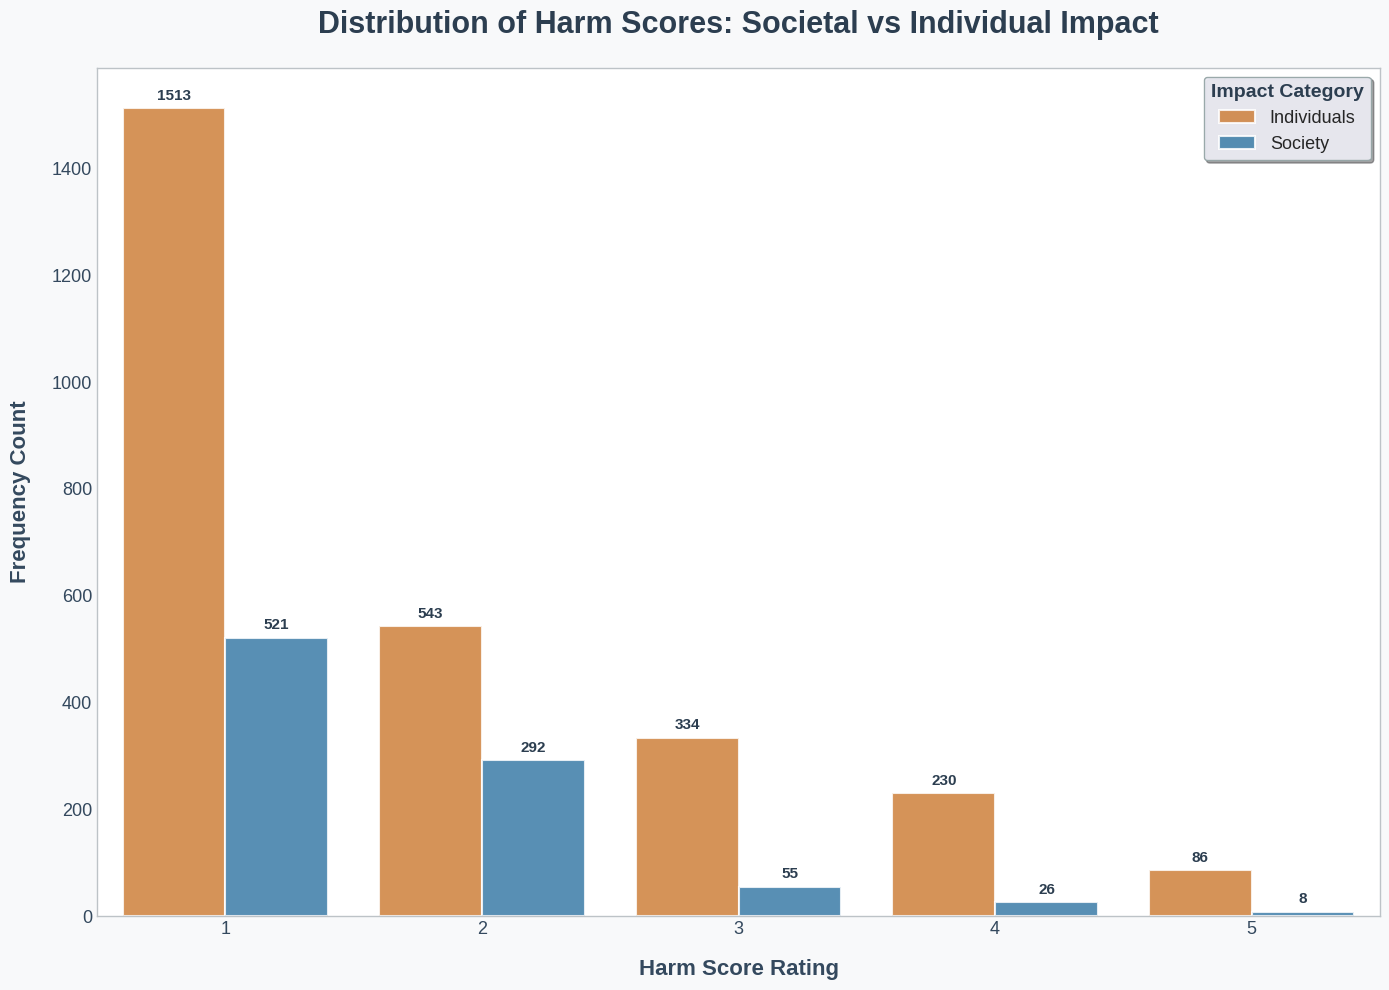

In [ ]:
# Melt the three individual columns into long format, keeping gender
df_individuals = df_harm.melt(
    id_vars=["gender"],
    value_vars=["harm_family_friend", "harm_acquaintance", "harm_stranger"],
    var_name="Relation",
    value_name="Score"
)
df_individuals["Harm Category"] = "Individuals"

# Society column as its own frame, keeping gender
df_society = df_harm[["gender", "harm_society"]].copy()
df_society = df_society.rename(columns={"harm_society": "Score"})
df_society["Harm Category"] = "Society"

# Combine datasets
df_two = pd.concat([df_individuals[["gender", "Score", "Harm Category"]],
                    df_society[["gender", "Score", "Harm Category"]]],
                   ignore_index=True)

# Create enhanced visualization
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(14, 10))

# Define sophisticated color palette
category_colors = {
    'Individuals': '#E67E22',  # Warm orange for personal relationships
    'Society': '#2980B9'       # Professional blue for societal impact
}

# Create the enhanced countplot
sns.countplot(data=df_two, x="Score", hue="Harm Category",
              palette=category_colors, alpha=0.85,
              edgecolor='white', linewidth=1.5)

# Enhance plot appearance
plt.title("Distribution of Harm Scores: Societal vs Individual Impact",
          fontsize=22, fontweight='bold', pad=25, color='#2C3E50')
plt.xlabel("Harm Score Rating", fontsize=16, fontweight='semibold',
           color='#34495E', labelpad=15)
plt.ylabel("Frequency Count", fontsize=16, fontweight='semibold',
           color='#34495E', labelpad=15)

# Customize tick parameters
plt.xticks(fontsize=13, color='#34495E', fontweight='medium')
plt.yticks(fontsize=13, color='#34495E', fontweight='medium')

# Enhance legend with better styling
legend = plt.legend(title="Impact Category", title_fontsize=14, fontsize=13,
                   loc='upper right', frameon=True, fancybox=True,
                   shadow=True, framealpha=0.95, edgecolor='#95A5A6')
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#2C3E50')

# Customize grid and background
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.6)
ax.set_axisbelow(True)
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold',
                color='#2C3E50', padding=4)

# Add subtle border styling
for spine in ax.spines.values():
    spine.set_color('#BDC3C7')
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.show()

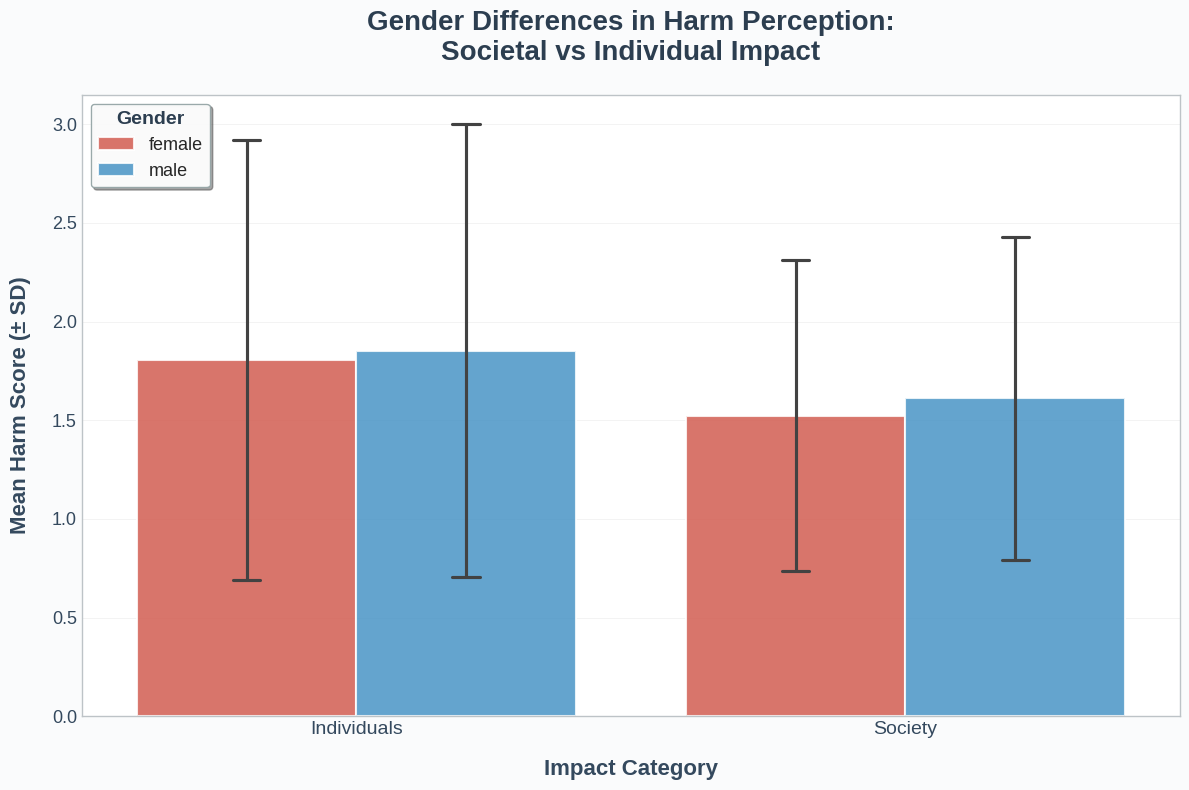

In [ ]:
# Enhanced gender differences visualization for Society vs Individuals
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Define sophisticated color palette for gender
gender_colors = {
    'Male': '#3498DB',      # Professional blue
    'Female': '#E74C3C',    # Elegant red
    'Other': '#9B59B6',     # Purple for other/non-binary
    'male': '#3498DB',      # Handle lowercase variations
    'female': '#E74C3C',
    'other': '#9B59B6'
}

# Create the enhanced barplot
sns.barplot(
    data=df_two,
    x="Harm Category",
    y="Score",
    hue="gender",
    palette=gender_colors,
    alpha=0.85,
    errorbar="sd",
    capsize=0.1,
    edgecolor='white',
    linewidth=1.5
)

# Enhance plot appearance
plt.title("Gender Differences in Harm Perception:\nSocietal vs Individual Impact",
          fontsize=20, fontweight='bold', pad=25, color='#2C3E50')
plt.xlabel("Impact Category", fontsize=16, fontweight='semibold',
           color='#34495E', labelpad=15)
plt.ylabel("Mean Harm Score (± SD)", fontsize=16, fontweight='semibold',
           color='#34495E', labelpad=15)

# Customize tick parameters
plt.xticks(fontsize=14, color='#34495E', fontweight='medium')
plt.yticks(fontsize=13, color='#34495E')

# Enhance legend
legend = plt.legend(title="Gender", title_fontsize=14, fontsize=13,
                   loc='upper left', frameon=True, fancybox=True,
                   shadow=True, framealpha=0.95, edgecolor='#95A5A6')
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#2C3E50')

# Customize grid and background
ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.4, axis='y')
ax.set_axisbelow(True)
fig.patch.set_facecolor('#FAFBFC')
ax.set_facecolor('#FFFFFF')

# Add subtle border styling
for spine in ax.spines.values():
    spine.set_color('#BDC3C7')
    spine.set_linewidth(1.0)

# Set y-axis to start from 0 for better comparison
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()